In [1]:
# Import packages
import os
from pathlib import Path

PROJECT_DIR = Path("/home/mcaskey/10XvParse/")
ANALYSIS_NAME = "Analysis_2"
SPECIES = "mouse"
INDEX_DIR = PROJECT_DIR / "Index" / SPECIES
ANALYSIS_DIR = Path.cwd() 
LOGCPM_TRANSFORM=True
CUTOFFS=[1000,300,300,300]
FULL_GENE_INFO_PATH = Path("gene_data/gene_comparisons_mini.csv")
PRESEQ_PATH = Path("preseq/mini")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
data_10x = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='10x', assay ="10x", data_title='10X Genomics', type='mini')
data_polyT = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='polyT', assay="parse_mini", data_title='Parse 3\'')
data_randO = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='randO', assay="parse_mini", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='parse', assay="parse_mini", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

PreSeq output already exists for all datasets.


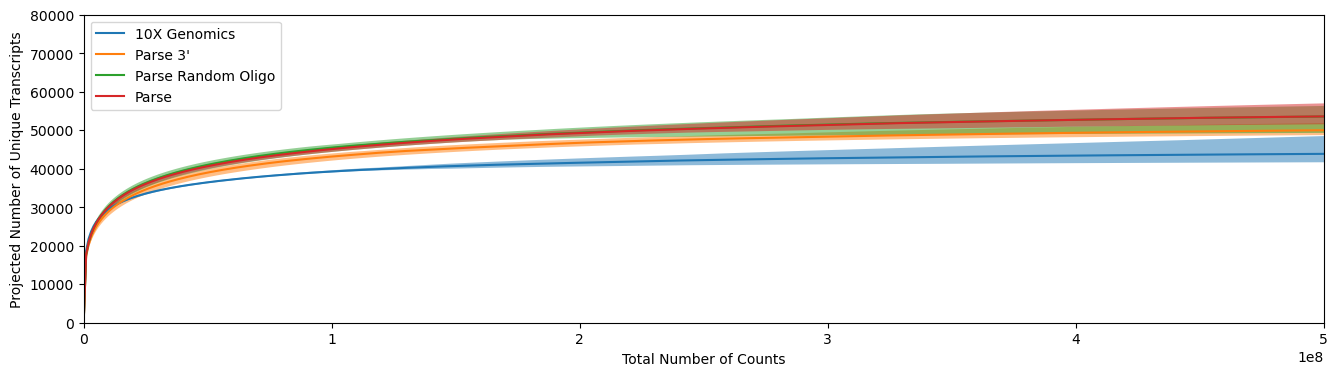

In [6]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
plotting.upsample(raw_datasets, PRESEQ_PATH, overwrite=False)
plotting.plot_upsample(raw_datasets, PRESEQ_PATH, xlim=5e8, ylim=8e4)

# Quality Control Comparison

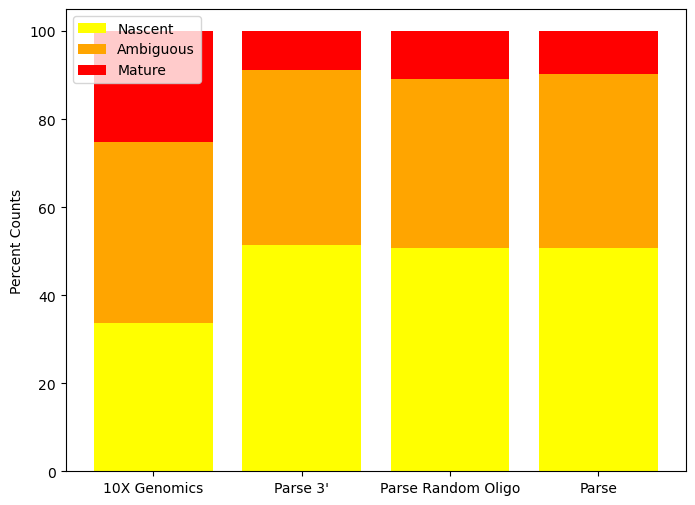

In [7]:
plotting.plot_nascent_mature_ratios(raw_datasets)

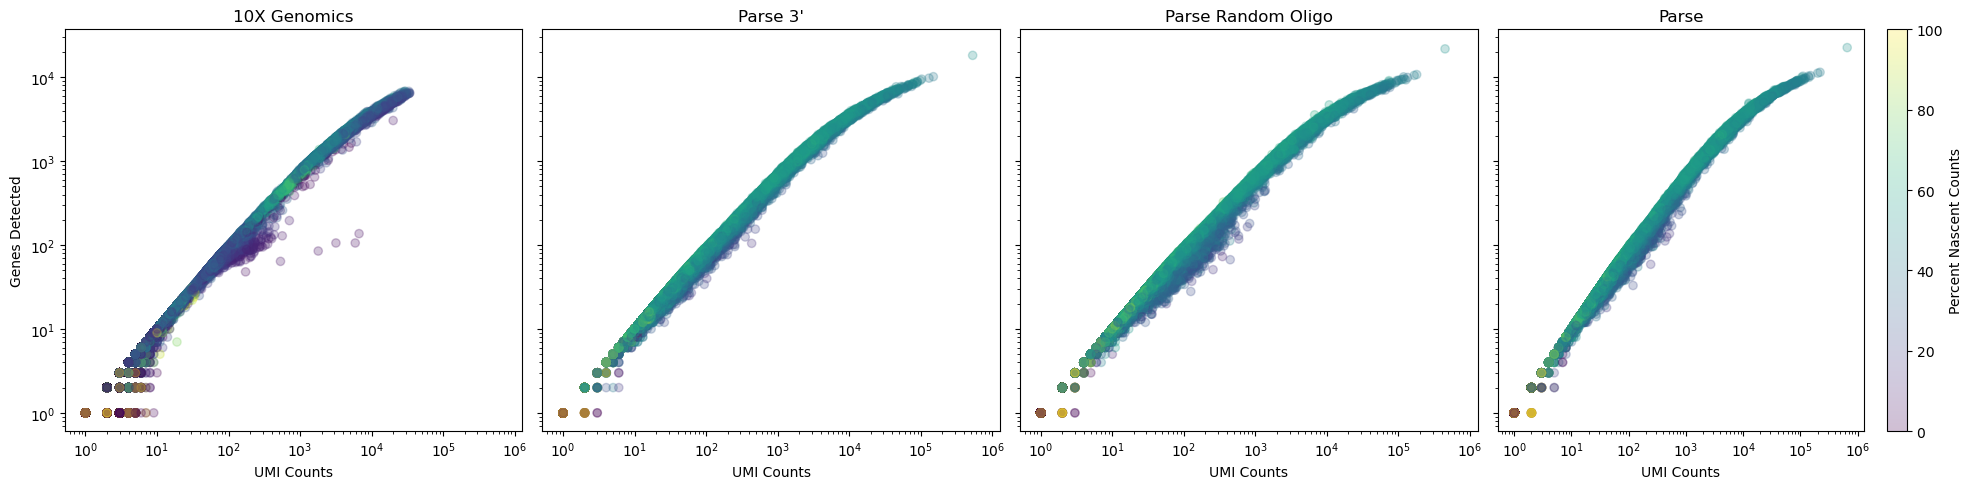

In [8]:
plotting.scatter_reads(raw_datasets)

In [9]:
gene_info = plotting.query_ensembl(PROJECT_DIR, index_dir=INDEX_DIR, species=SPECIES, overwrite=True) 

In [10]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


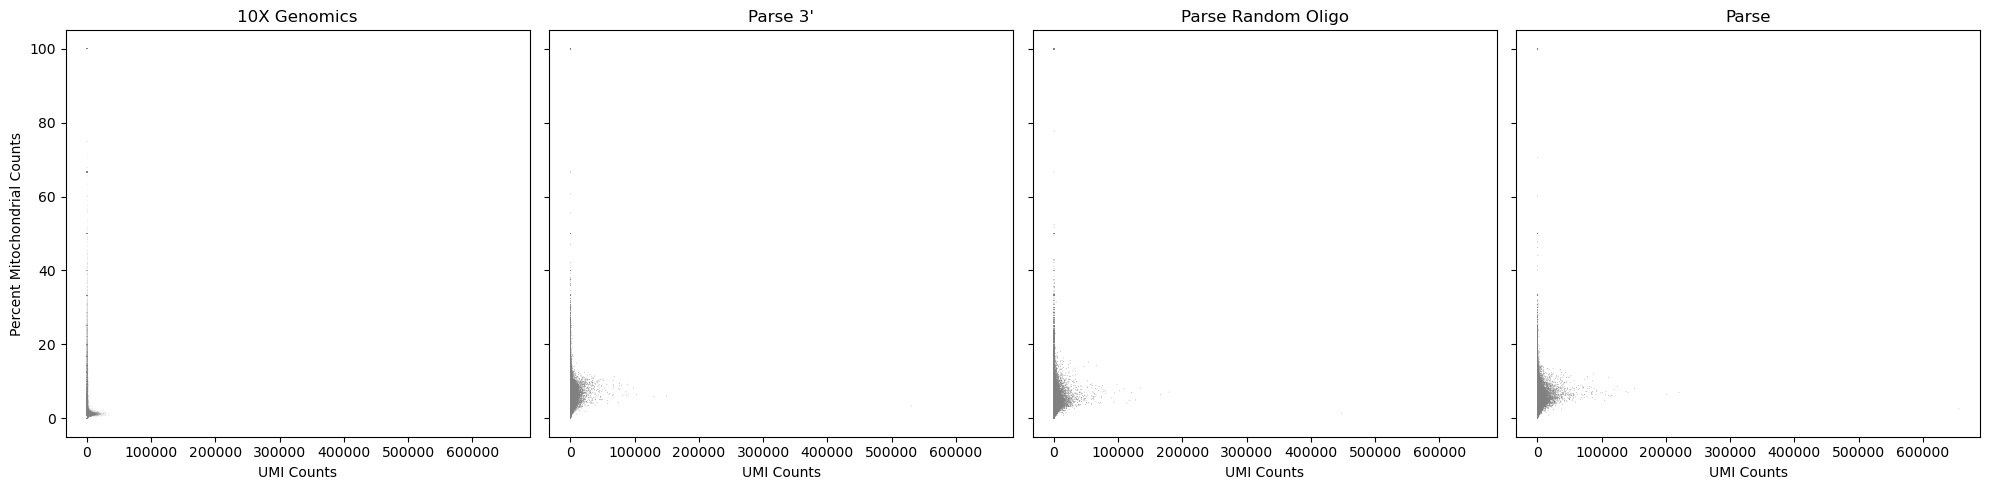

In [11]:
plotting.mito_scatter(raw_datasets)

12,336 cells passed the 1000 UMI threshold for 10X Genomics
Applied CPM normalization and log1p transformation to the filtered data.
20,513 cells passed the 300 UMI threshold for Parse 3'
Applied CPM normalization and log1p transformation to the filtered data.
18,421 cells passed the 300 UMI threshold for Parse Random Oligo
Applied CPM normalization and log1p transformation to the filtered data.
20,854 cells passed the 300 UMI threshold for Parse
Applied CPM normalization and log1p transformation to the filtered data.


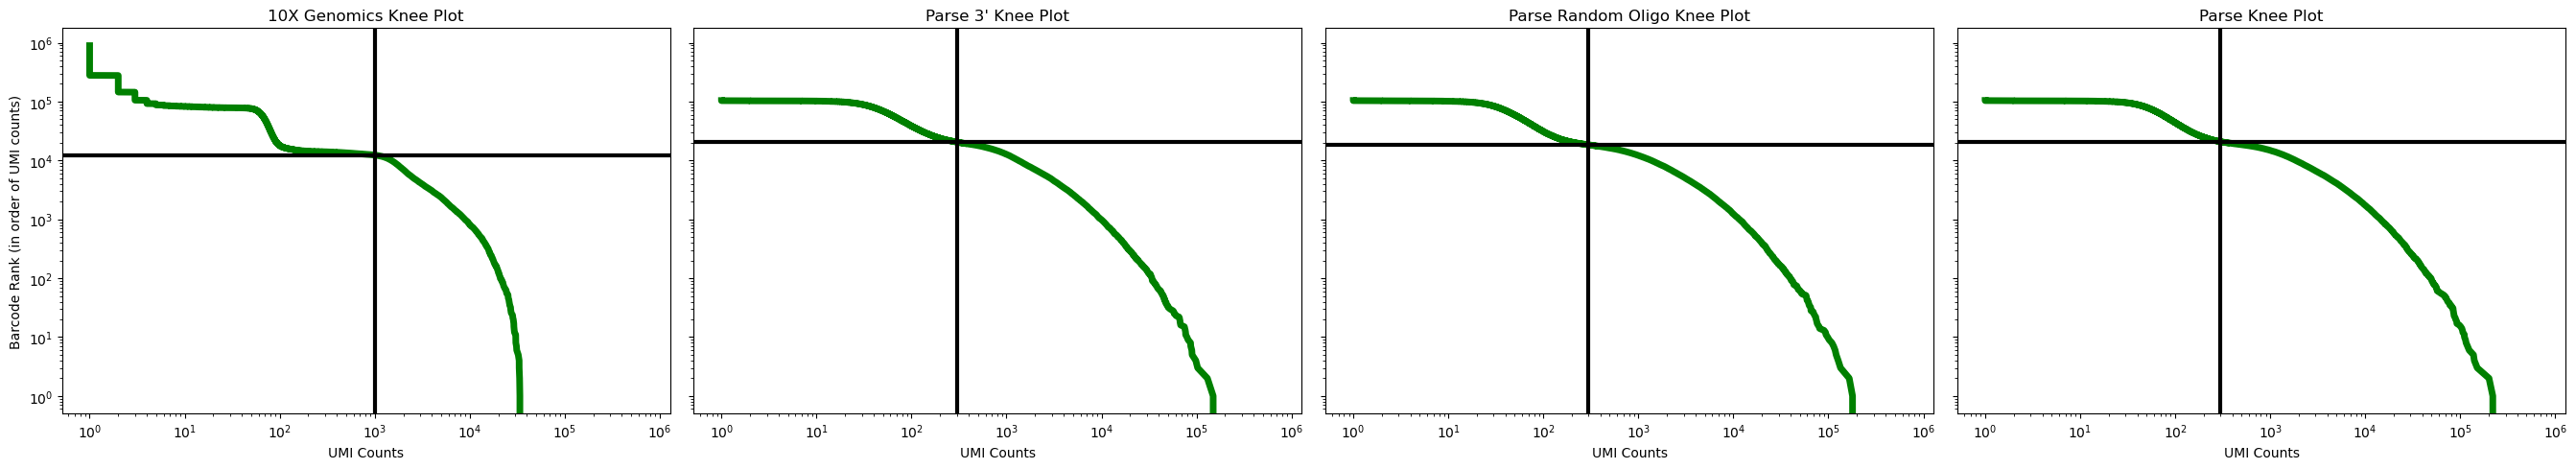

In [12]:
datasets = plotting.knee_plot(raw_datasets, cutoffs=CUTOFFS, transform=LOGCPM_TRANSFORM)

In [13]:
gene_info = plotting.update_gene_info(gene_info, datasets, FULL_GENE_INFO_PATH)

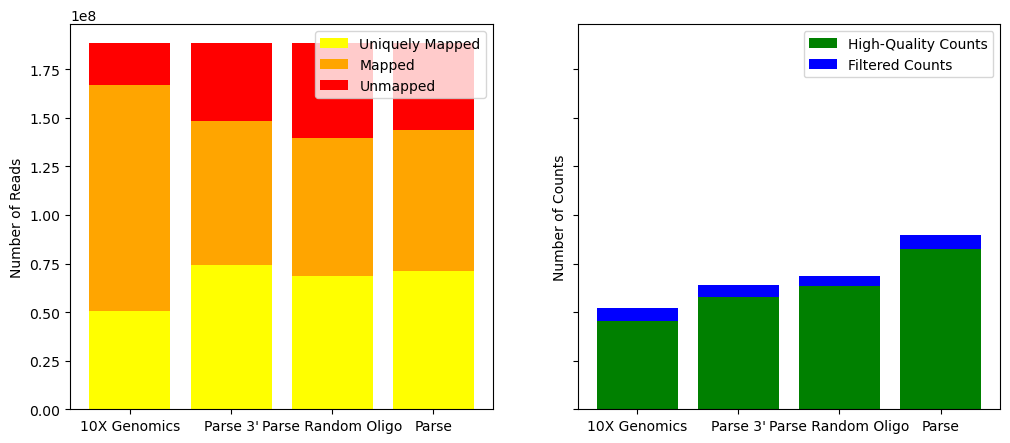

In [14]:
plotting.plot_filtering_metrics(datasets)

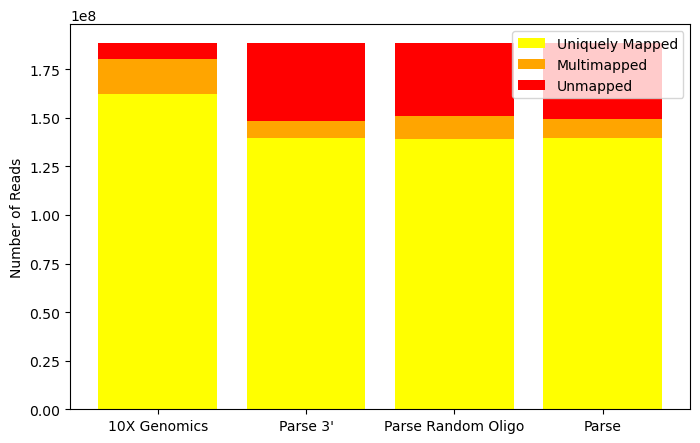

In [15]:
plotting.plot_filtering_metrics_star(datasets)

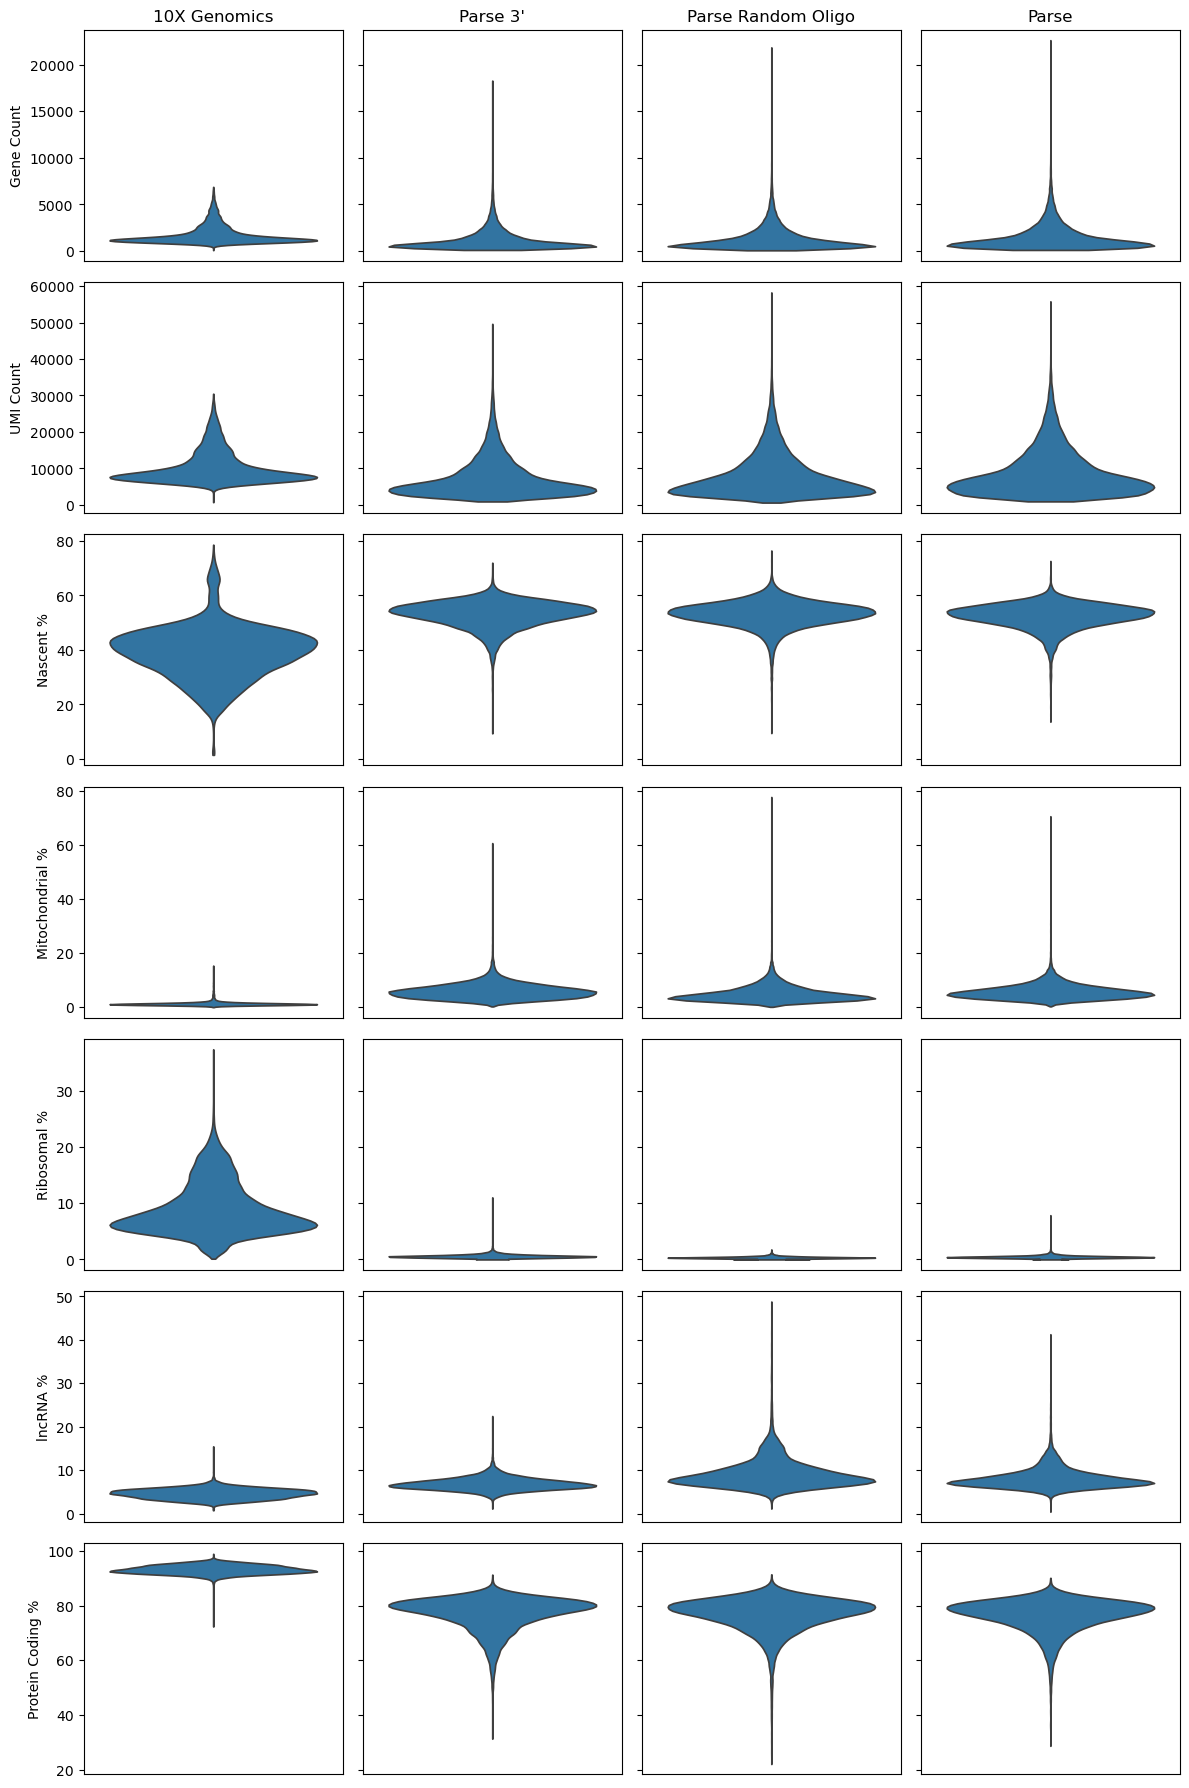

In [16]:
groups = ['n_genes', 'n_counts', 'percent_nascent', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Nascent %', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names)

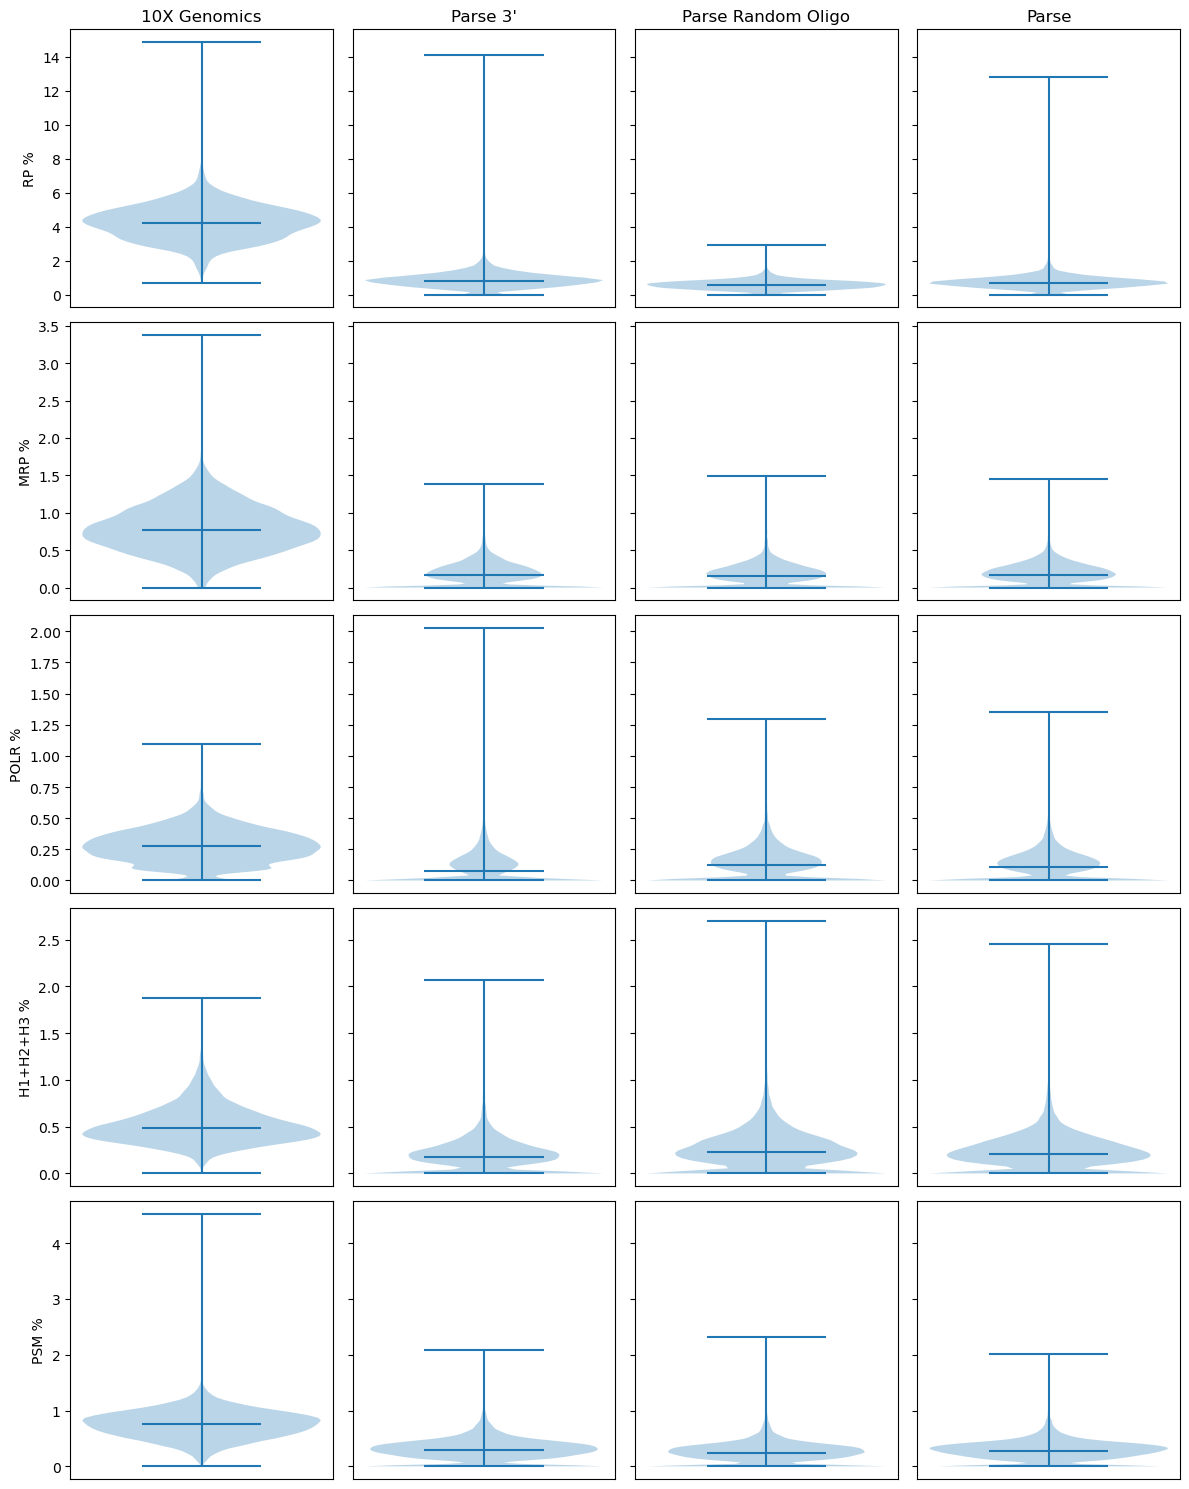

In [17]:
# Transcritptional Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["RP", "MRP", "POLR", "H1+H2+H3", "PSM"])

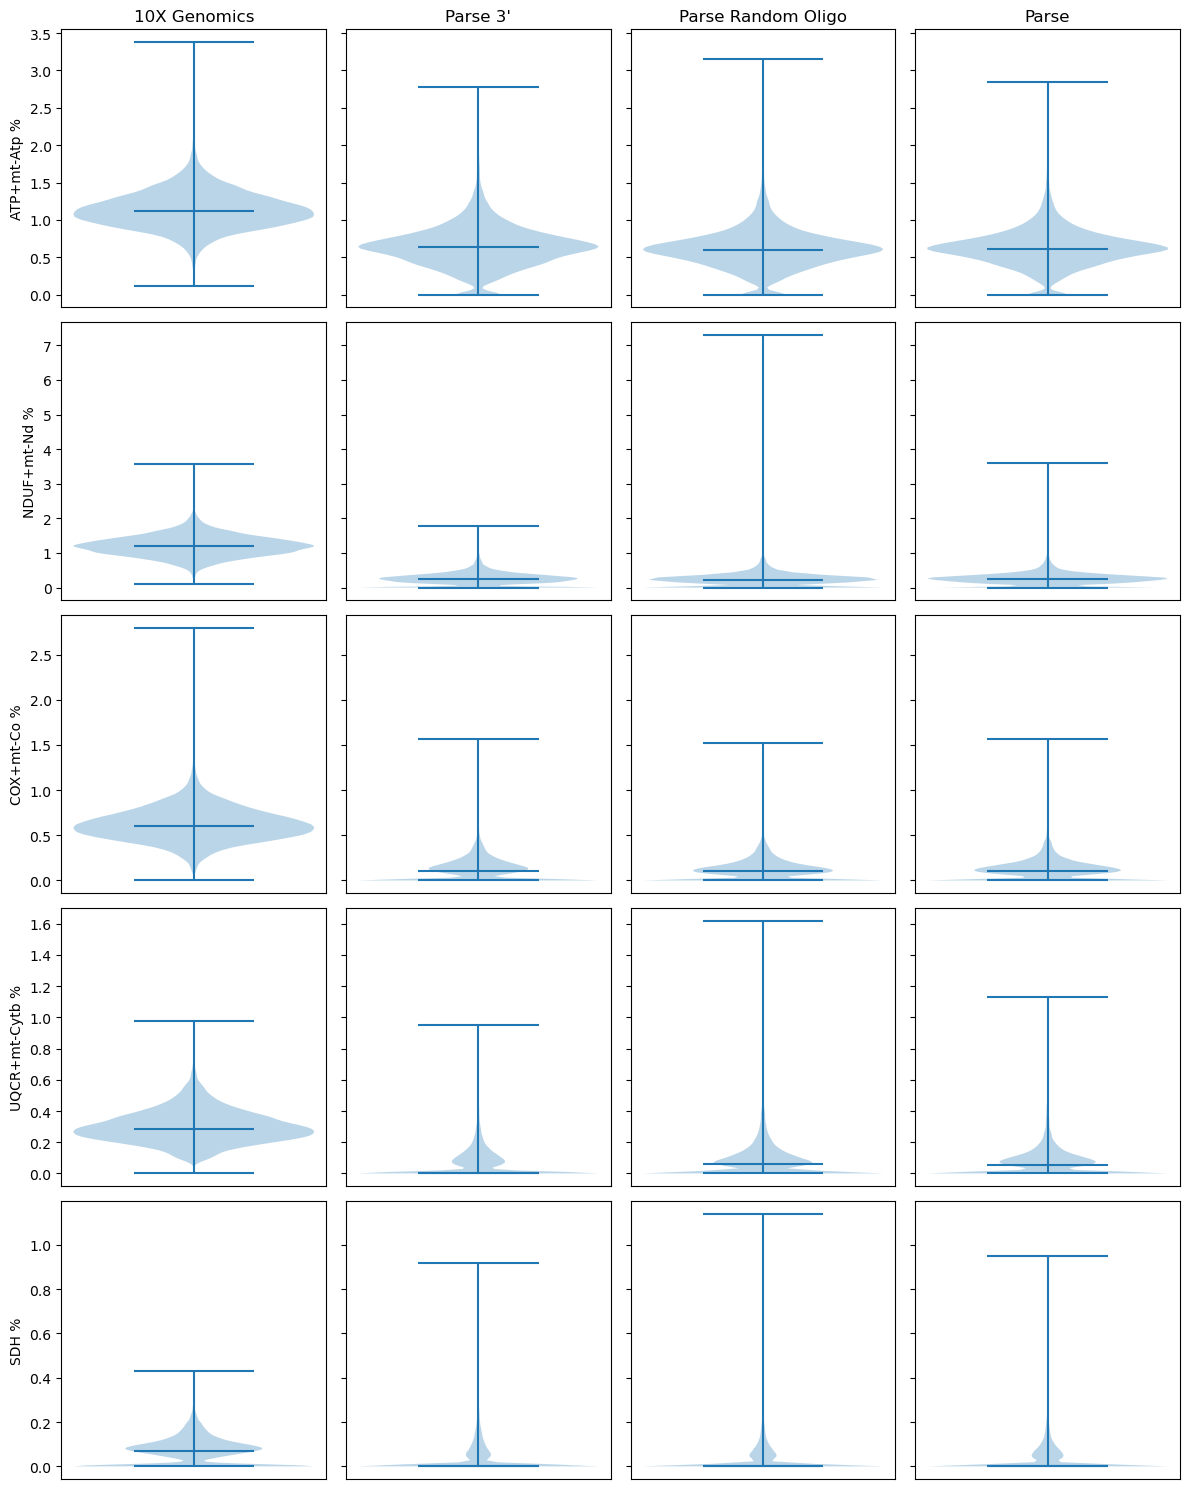

In [18]:
# OXPHOS Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["ATP+mt-Atp", "NDUF+mt-Nd", "COX+mt-Co", "UQCR+mt-Cytb", "SDH"])

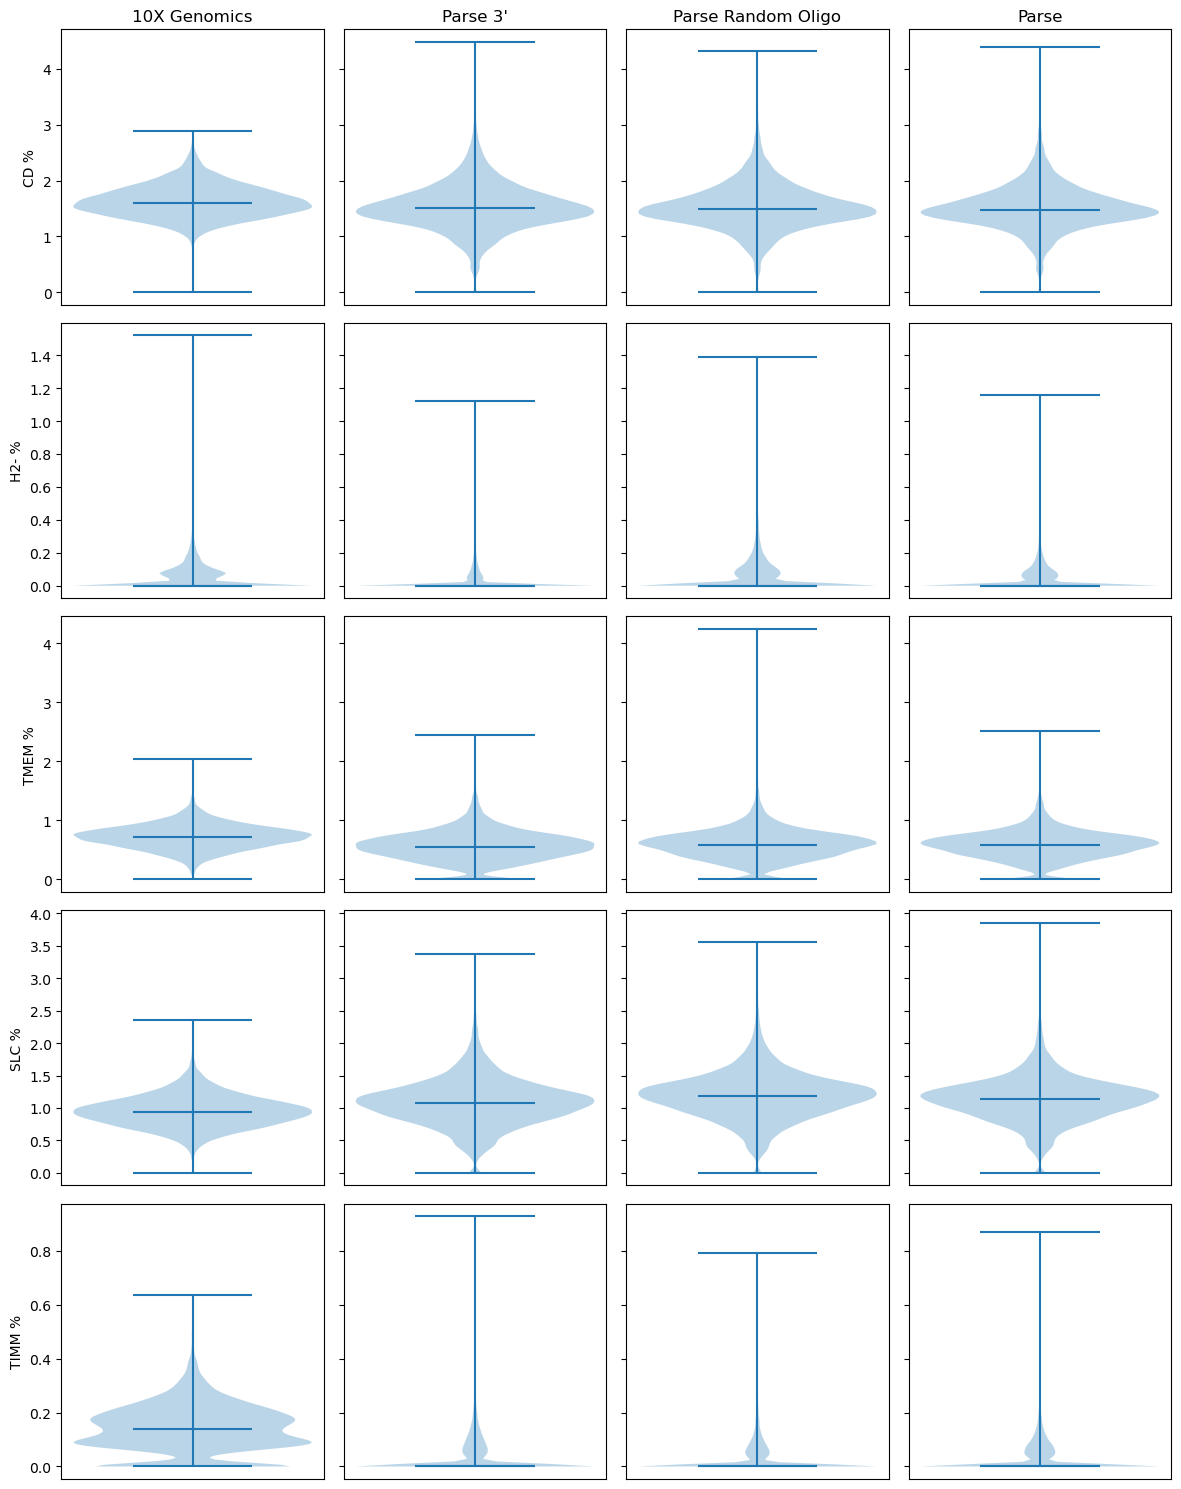

In [19]:
# cell suface and transmembrane protein gene family percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["CD", "H2-", "TMEM", "SLC", "TIMM"])

# Read/Gene Comparisons

In [20]:
# Pan-leukocyte anchor
pan_leukocyte = ["Ptprc"]

# Early thymic progenitor & T-lineage commitment (ETP / DN1–DN2)
early_progenitor_commitment = ["Kit", "Cd44", "Bcl11b", "Tcf7", "Gata3"]

# Rearrangement & β-selection (DN3–DN4)
rearrangement_beta_selection = ["Il2ra", "Rag1", "Rag2", "Ptcra", "Dntt"]

# Proliferation
proliferation = ["Mki67"]

# DP identity & TCR/CD3
dp_identity = ["Cd4", "Cd8a", "Cd8b1", "Cd24a", "Cd3e", "Cd3d", "Cd3g"]

# Positive selection & TCR signal strength
positive_selection_signal = ["Themis", "Cd69", "Cd5", "Cd28", "Nr4a1"]

# CD4 vs CD8 lineage commitment
lineage_commitment = ["Zbtb7b", "Runx3"]

# SP maturation & thymic egress
sp_maturation_egress = ["Ccr9", "Ccr7", "Sell", "Klf2", "S1pr1"]

# Regulatory T cells
treg = ["Foxp3"]

# Survival / negative-selection axis
survival_negative_selection = ["Bcl2", "Bcl2l11"]

# γδ / innate-like lineage
gd_innate = ["Zbtb16"]

# Stromal & myeloid contamination flags (QC) — NOT thymocyte-intrinsic
qc_stromal_myeloid = ["Aire", "Krt5", "Krt8", "Krt18", "Lyz2"] #"Krt14"

thymocyte_markers = {
    "Pan Leukocyte": pan_leukocyte,
    "Early Progenitor Commitment": early_progenitor_commitment,
    "Rearrangement/Beta Selection": rearrangement_beta_selection,
    "Proliferation": proliferation,
    "DP Identity": dp_identity,
    "Positive Selection Signal": positive_selection_signal,
    "Lineage Commitment": lineage_commitment,
    "SP Maturation Egress": sp_maturation_egress,
    "Treg": treg,
    "Survival Negative Selection": survival_negative_selection,
    "GD Innate": gd_innate,
    "Stromal/Myeloid QC": qc_stromal_myeloid,
}

# TCR loci — PREFIXES (match by startswith, not exact)
tcr_loci_prefixes = ["Trav", "Trbv", "Trgv", "Trdv"]

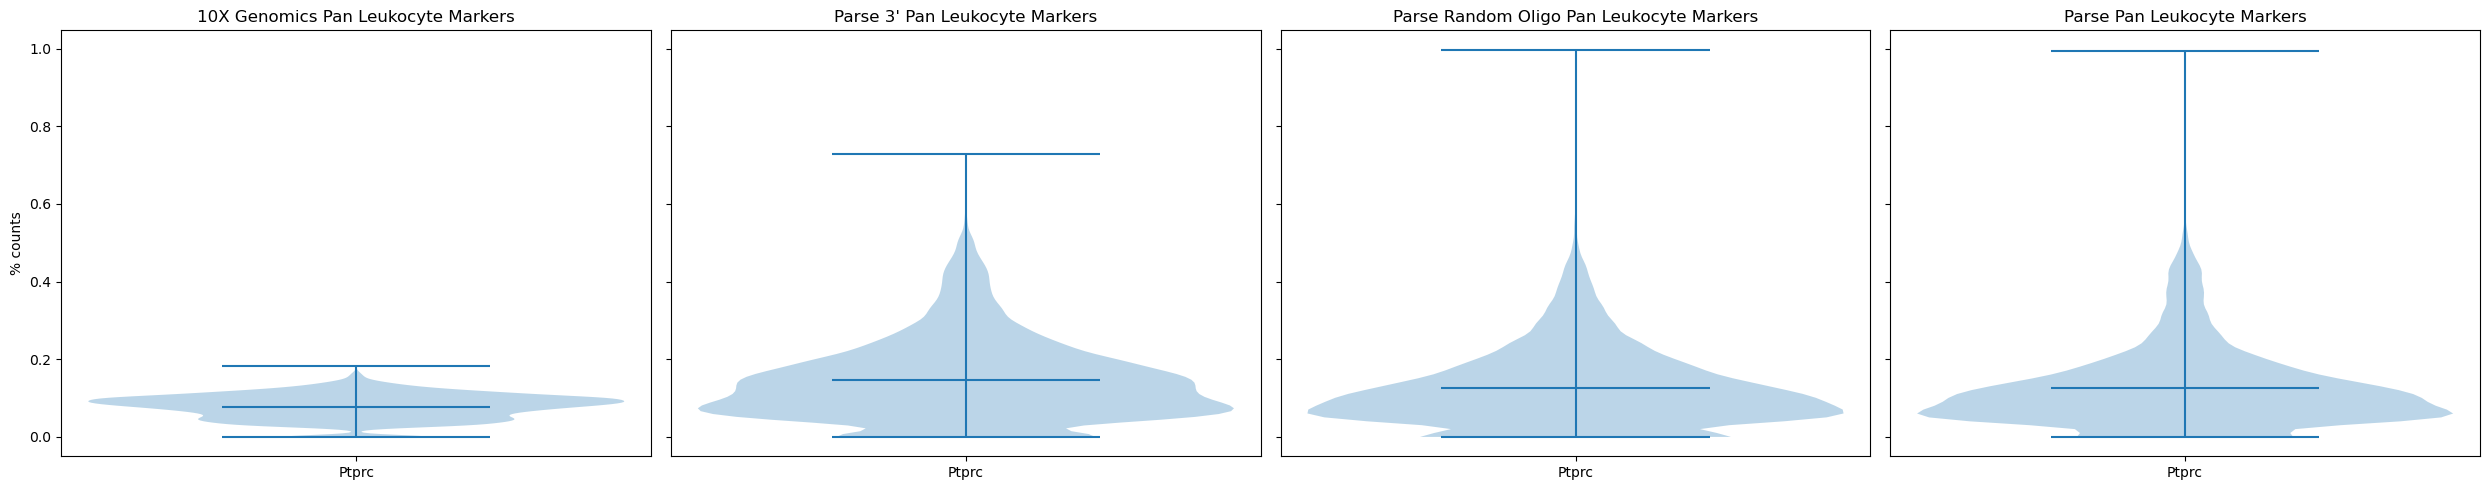

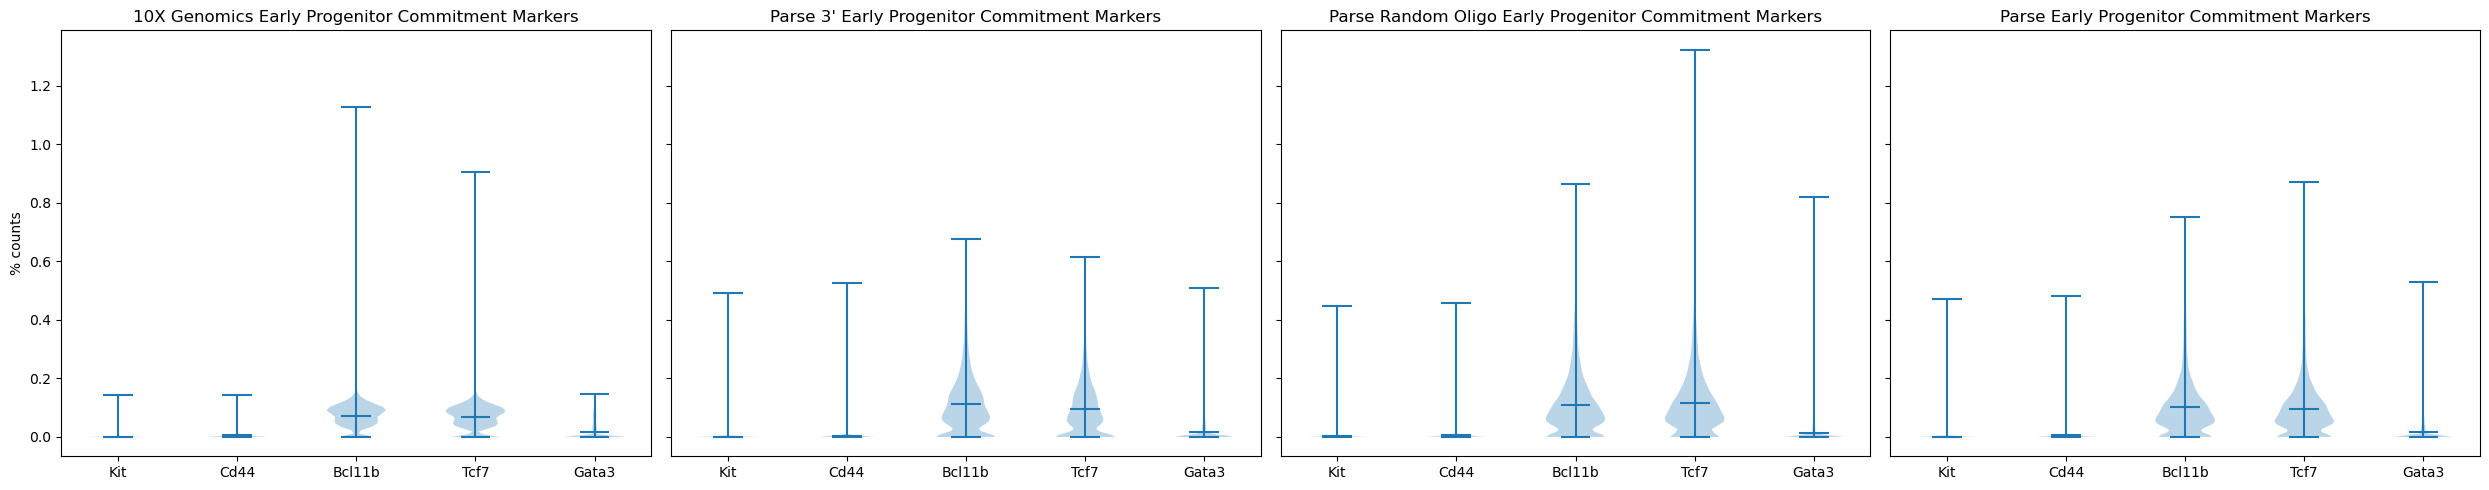

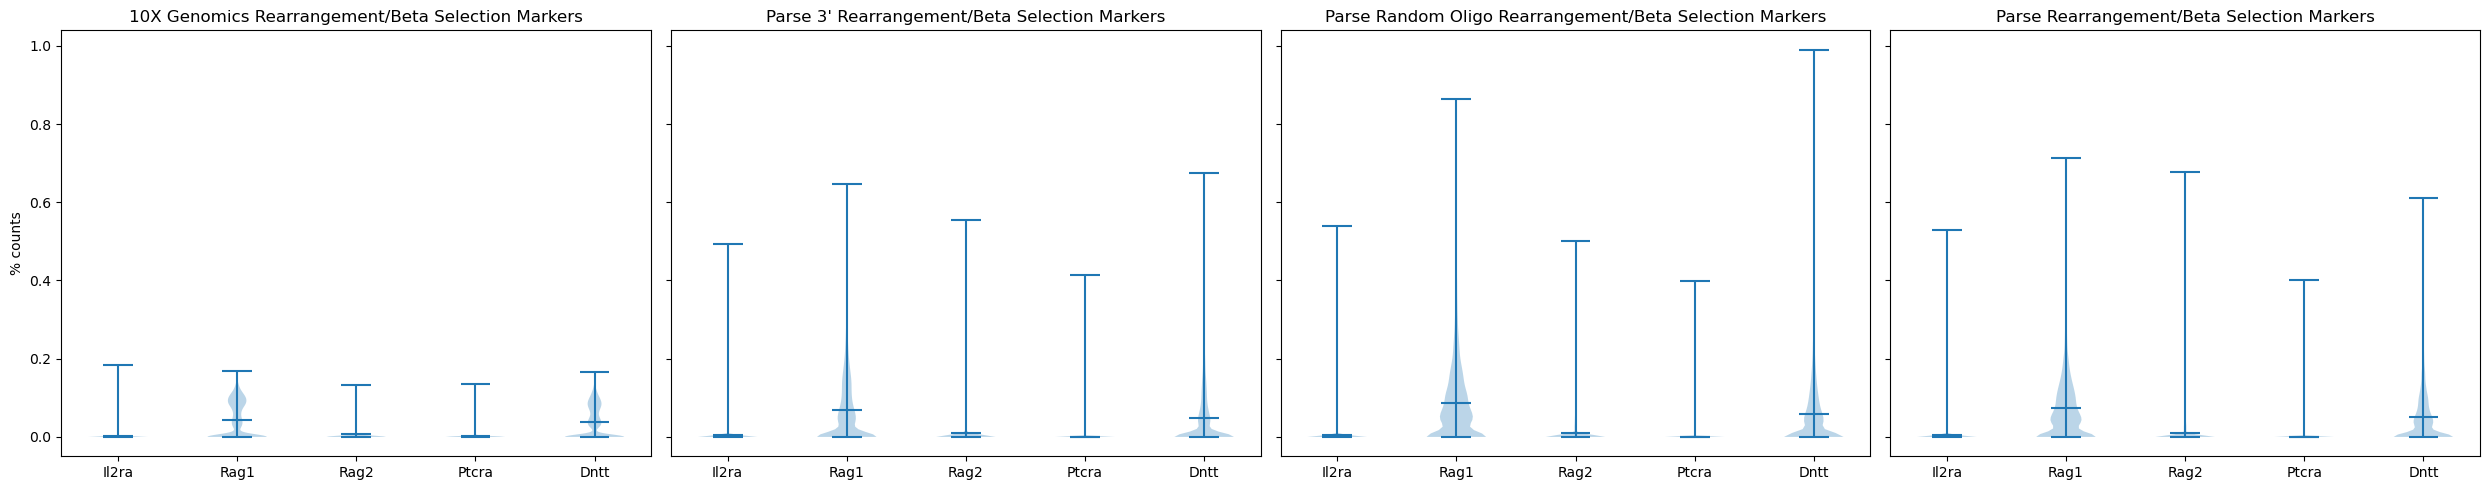

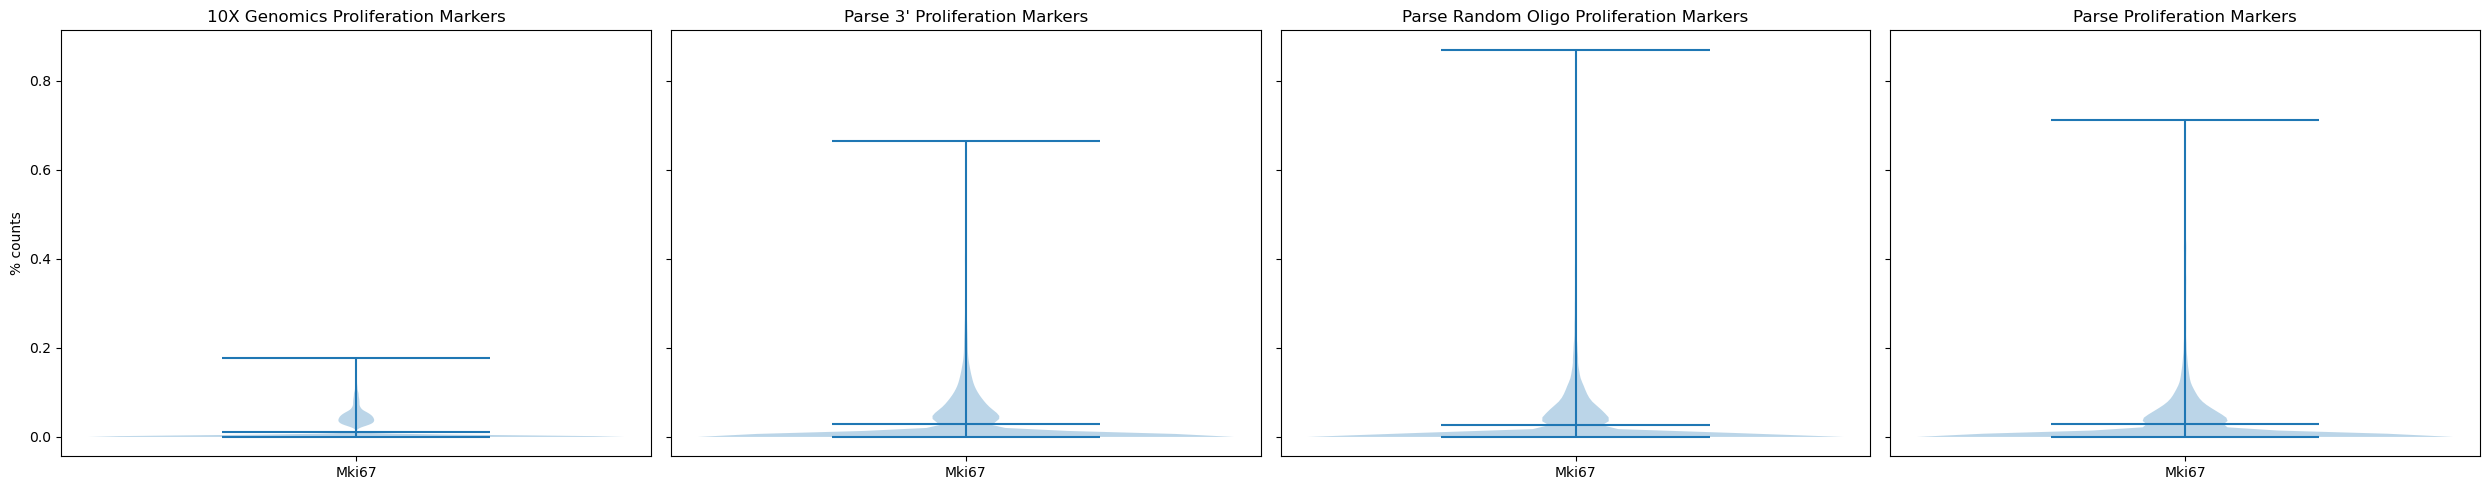

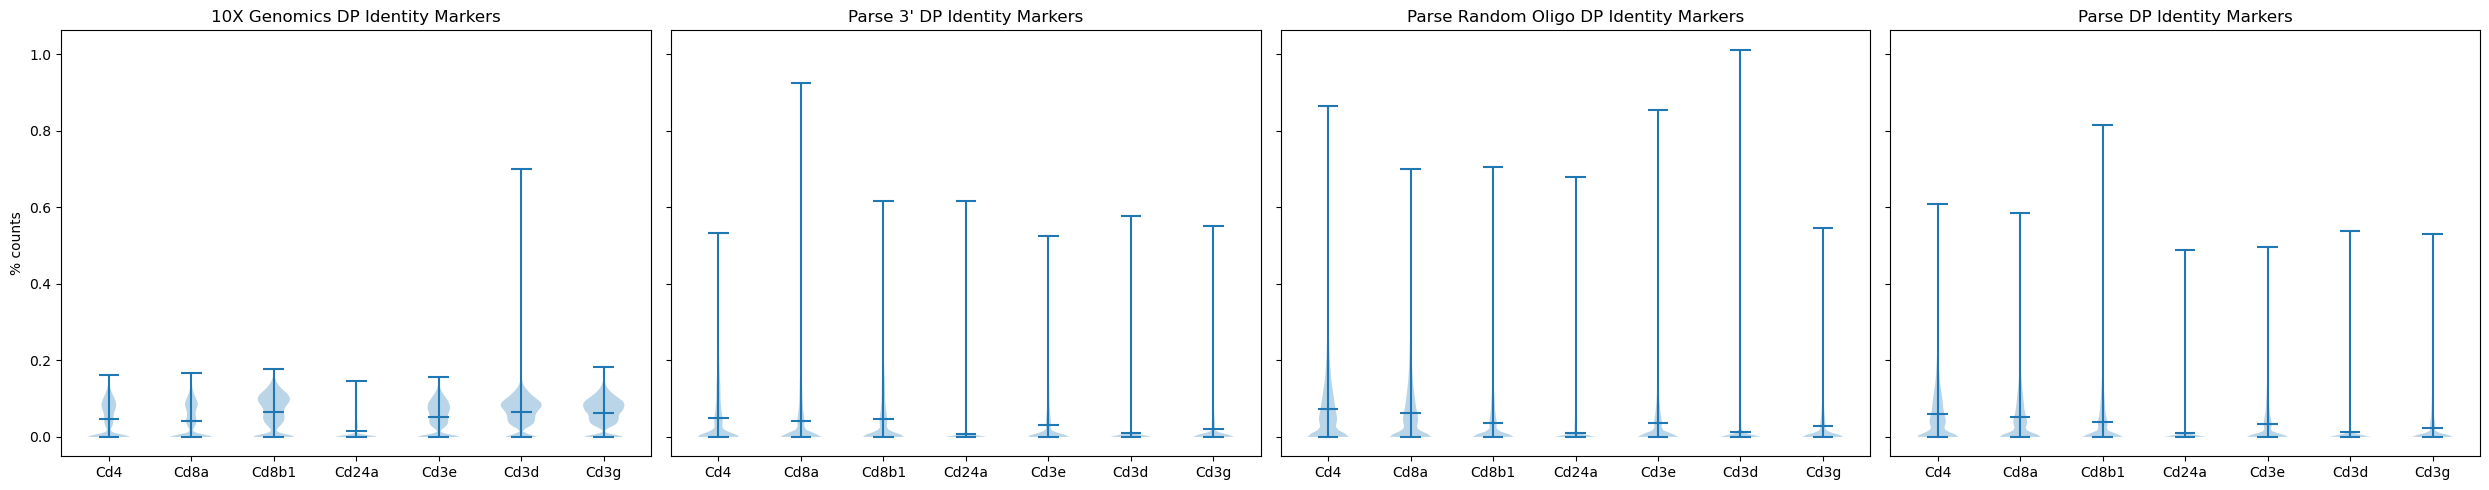

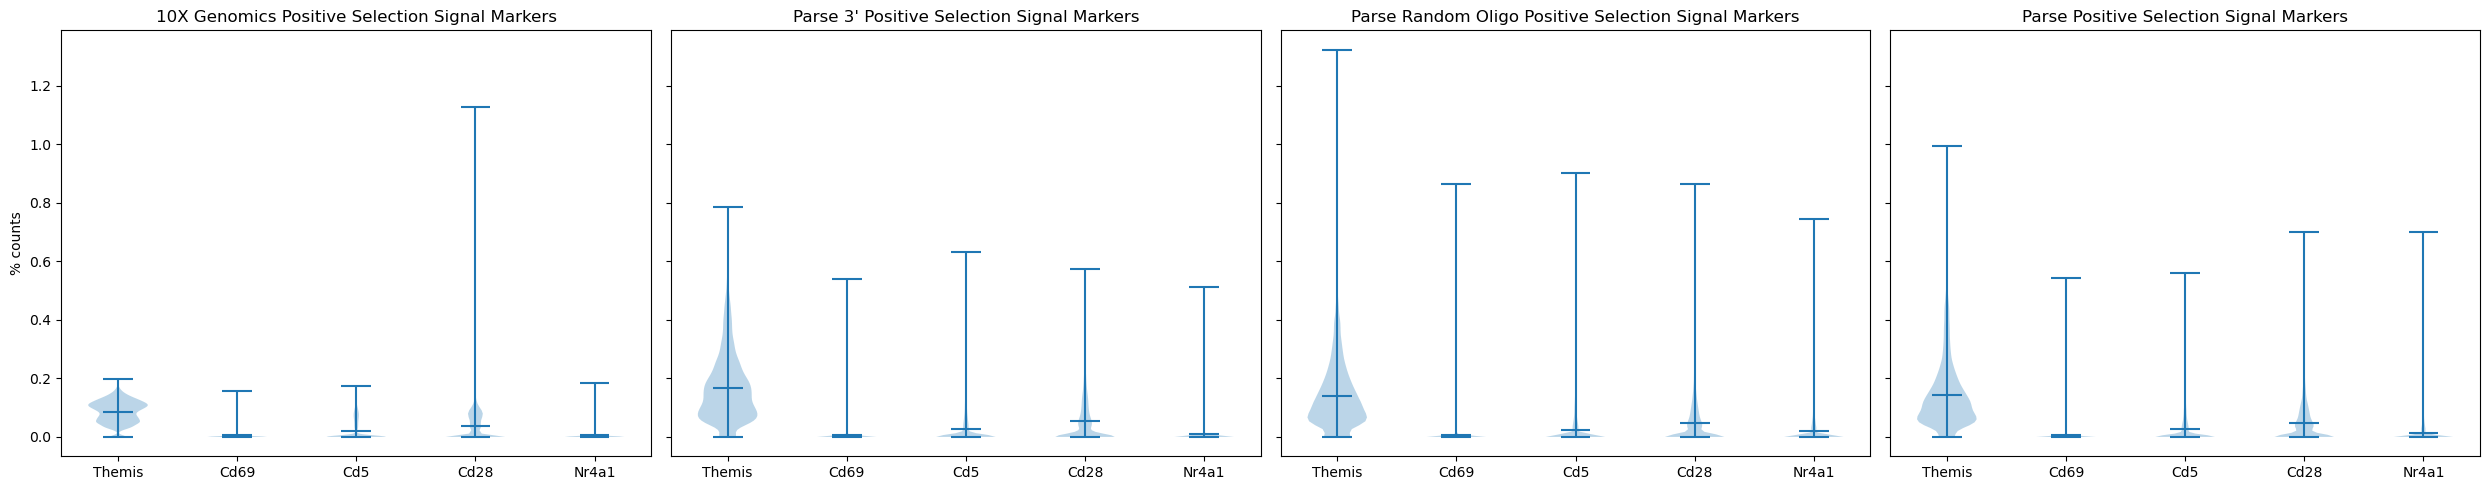

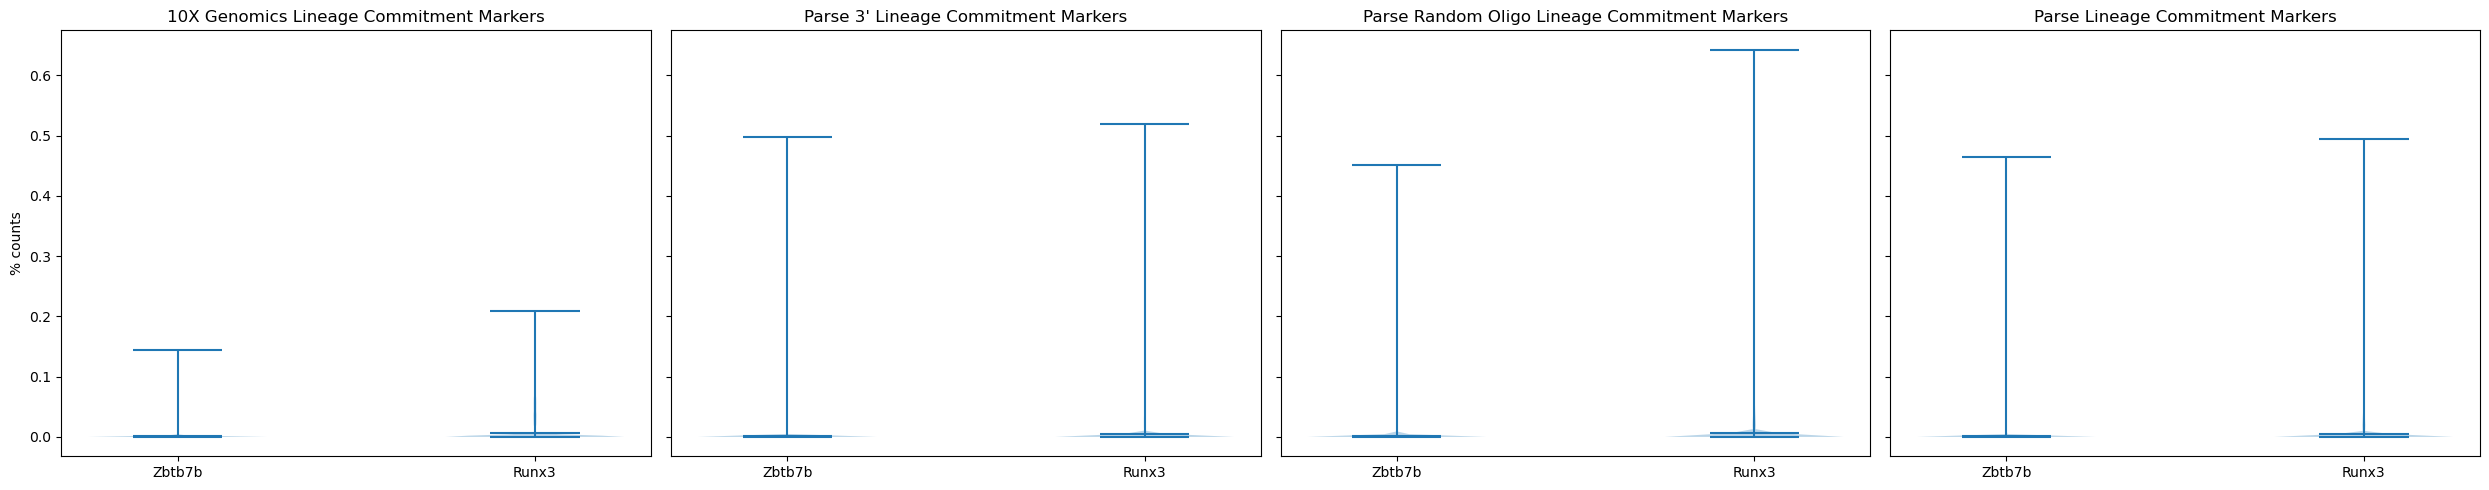

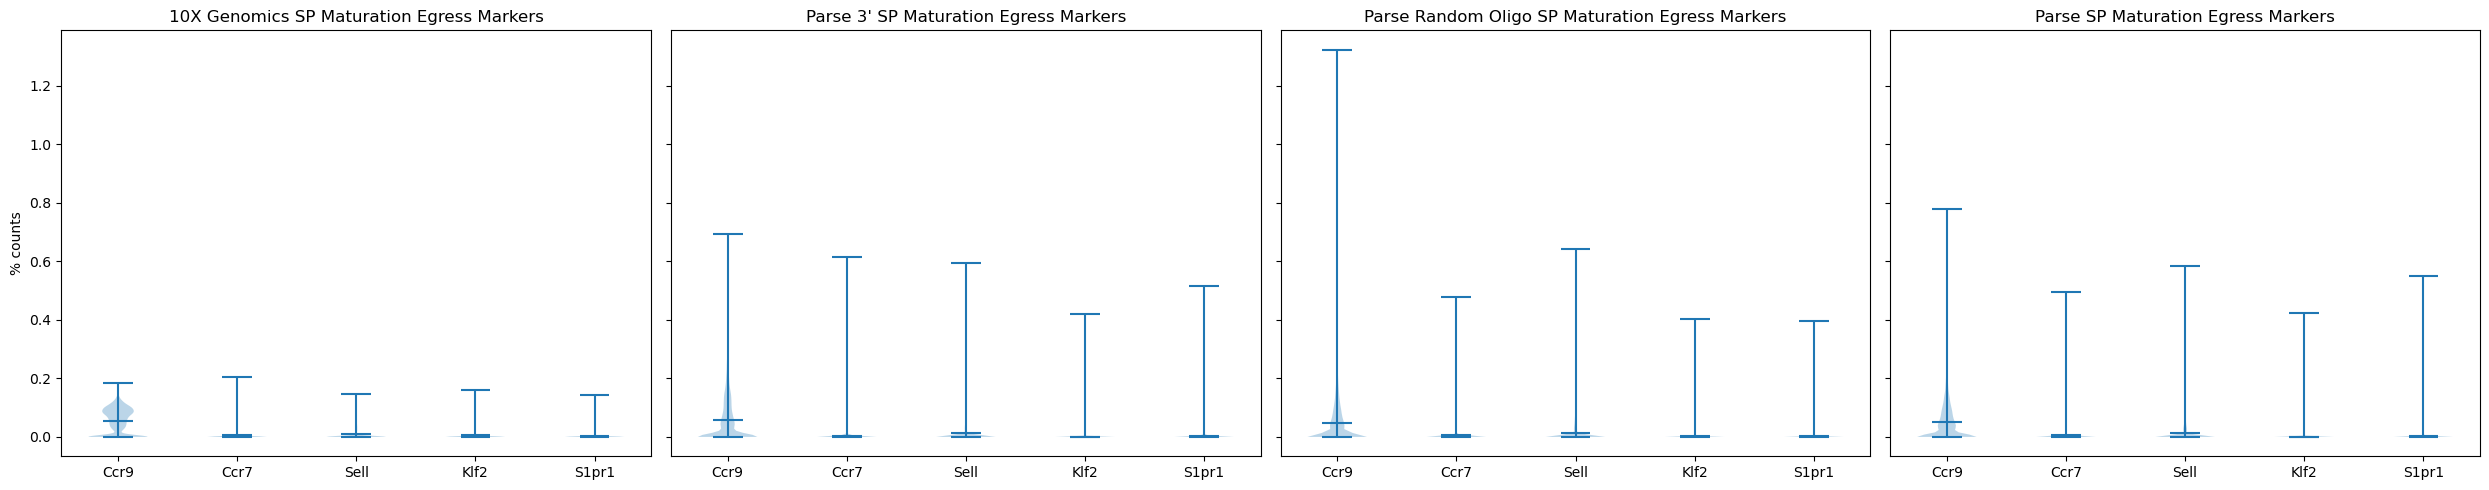

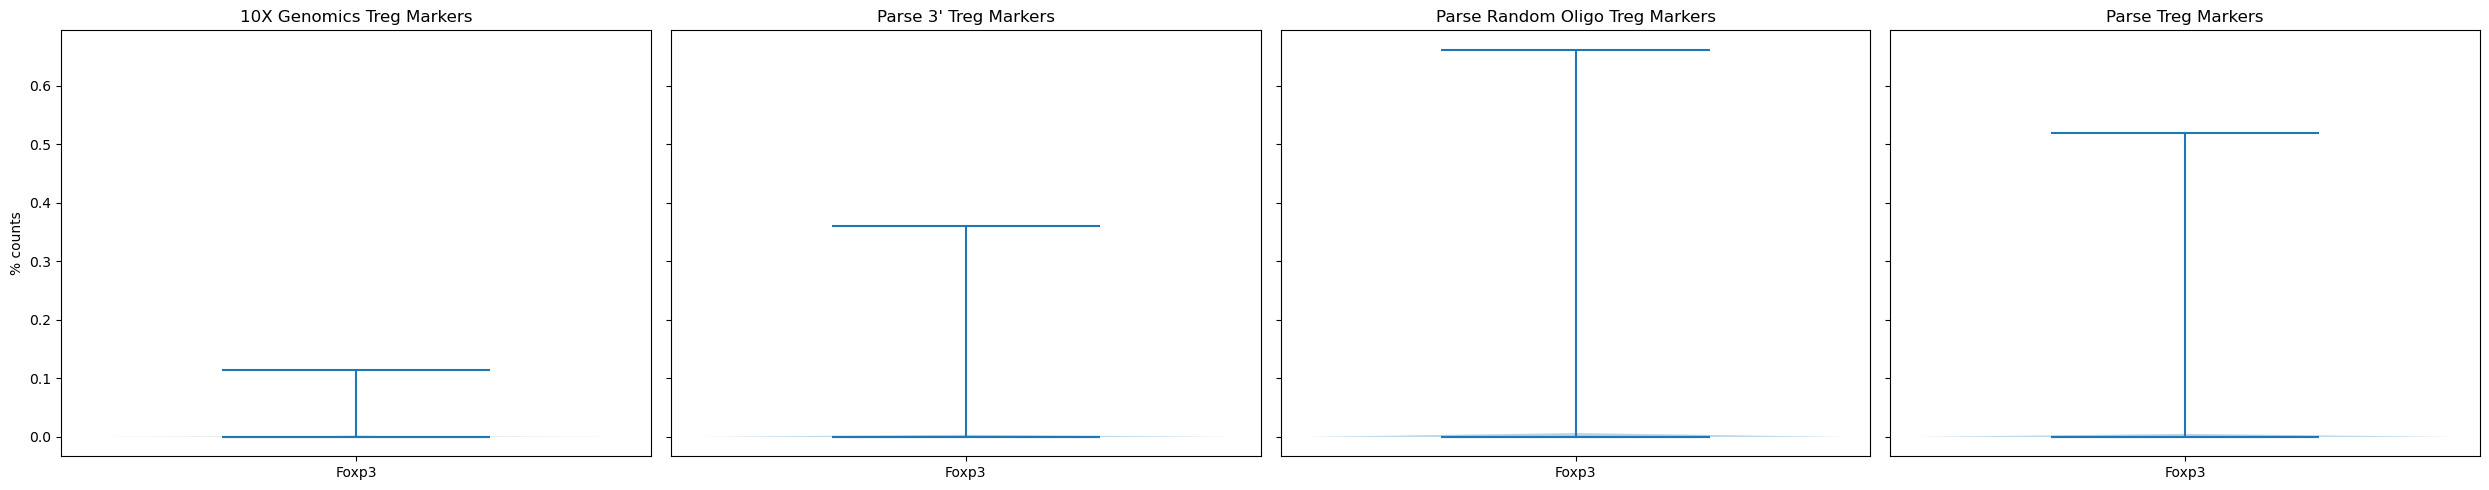

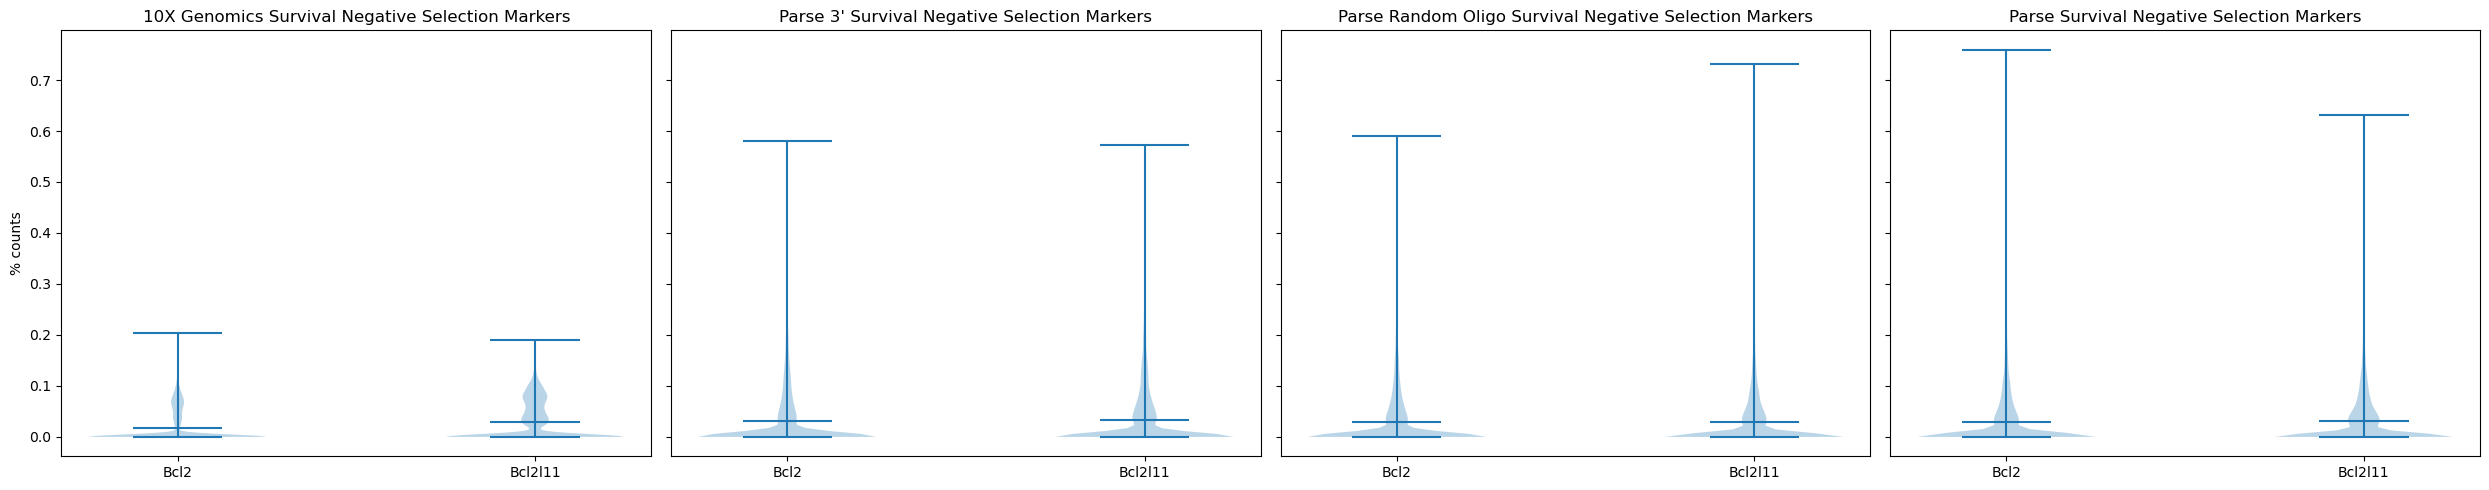

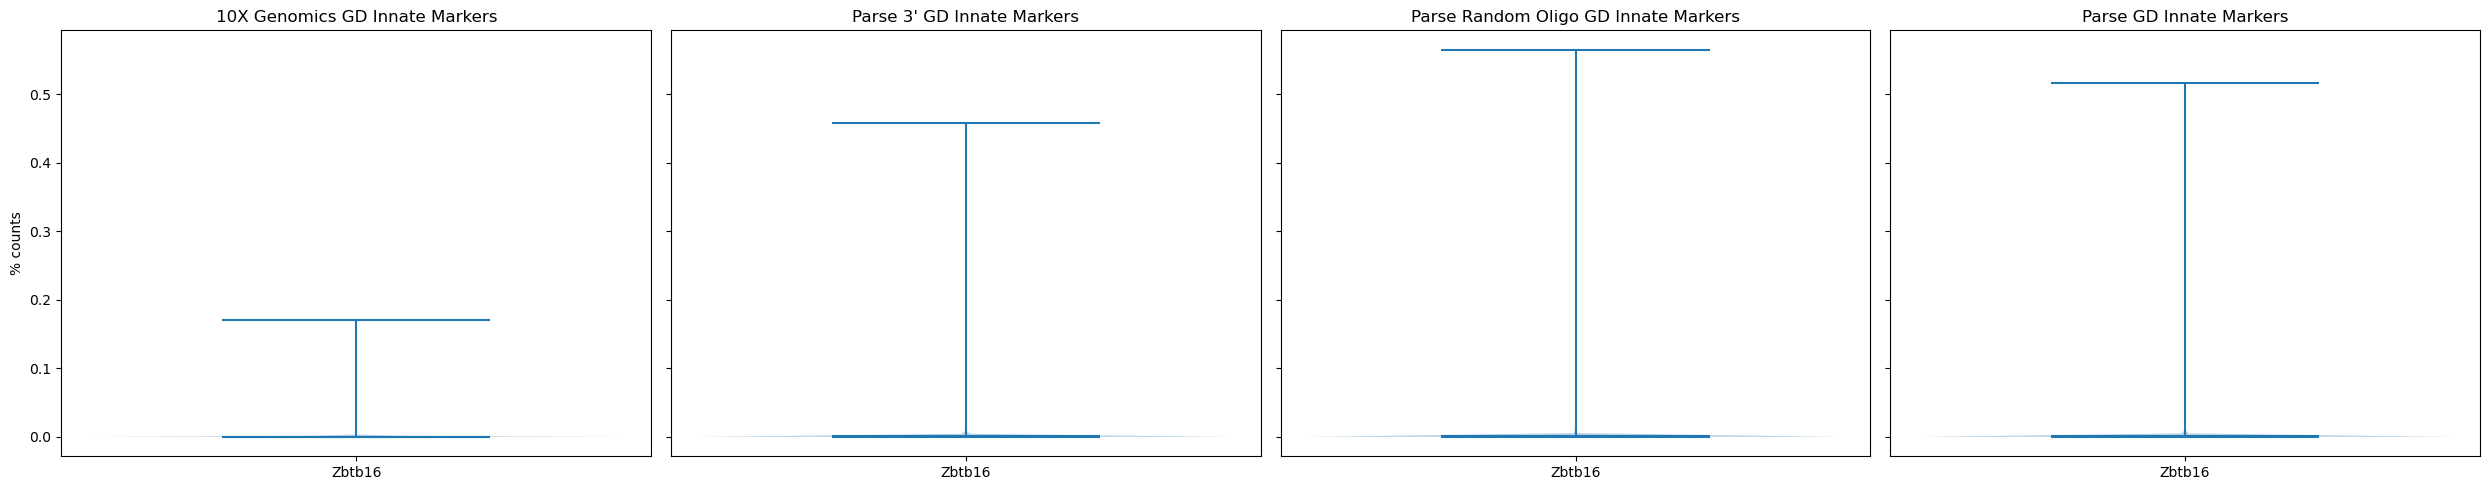

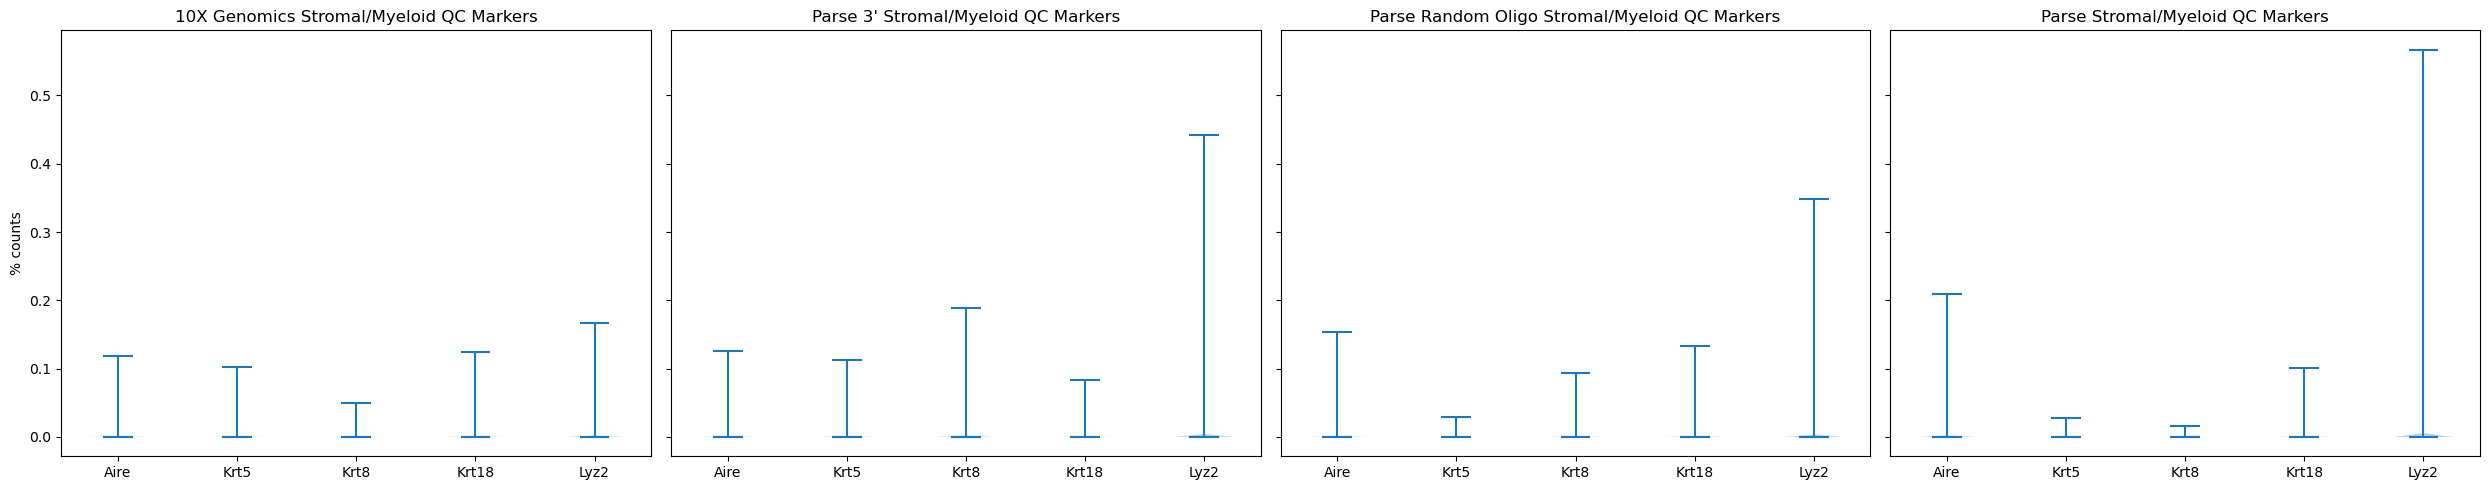

In [21]:
for marker_set_name in thymocyte_markers.keys():
    plotting.marker_genes(datasets, thymocyte_markers[marker_set_name], plot_title=marker_set_name + " Markers")

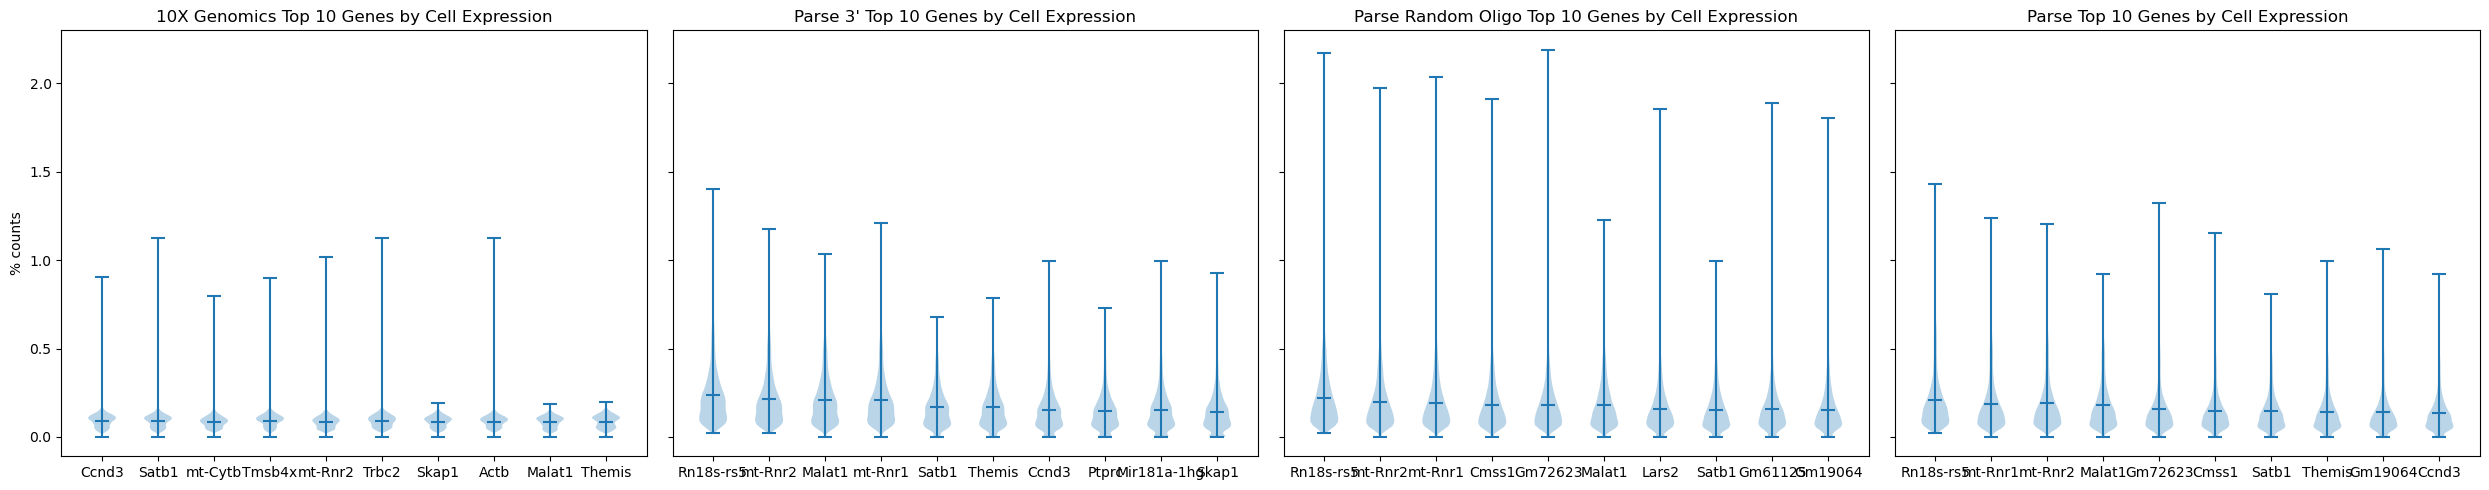

In [22]:
plotting.top_gene_cell_expression(datasets)

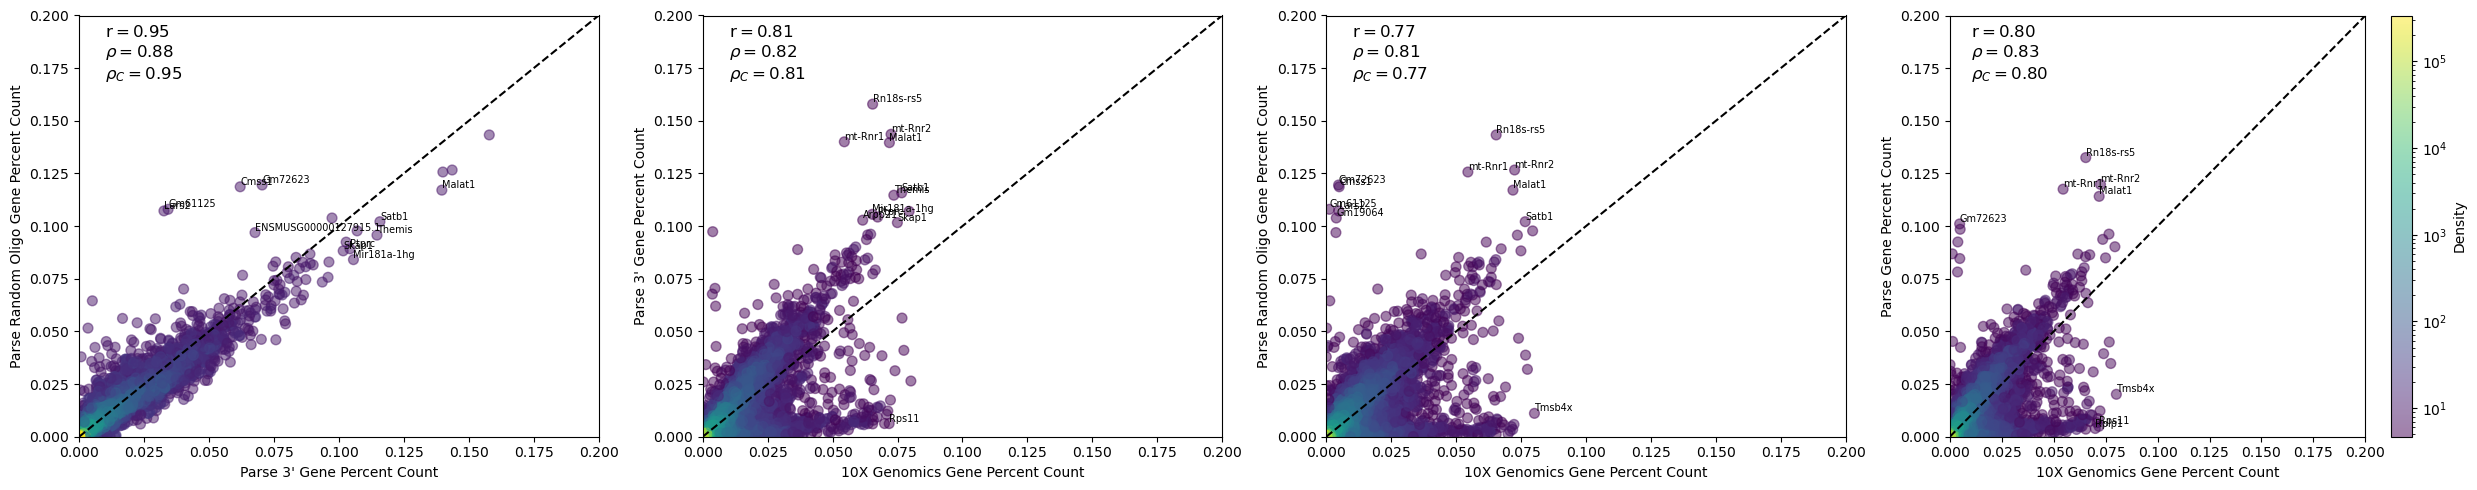

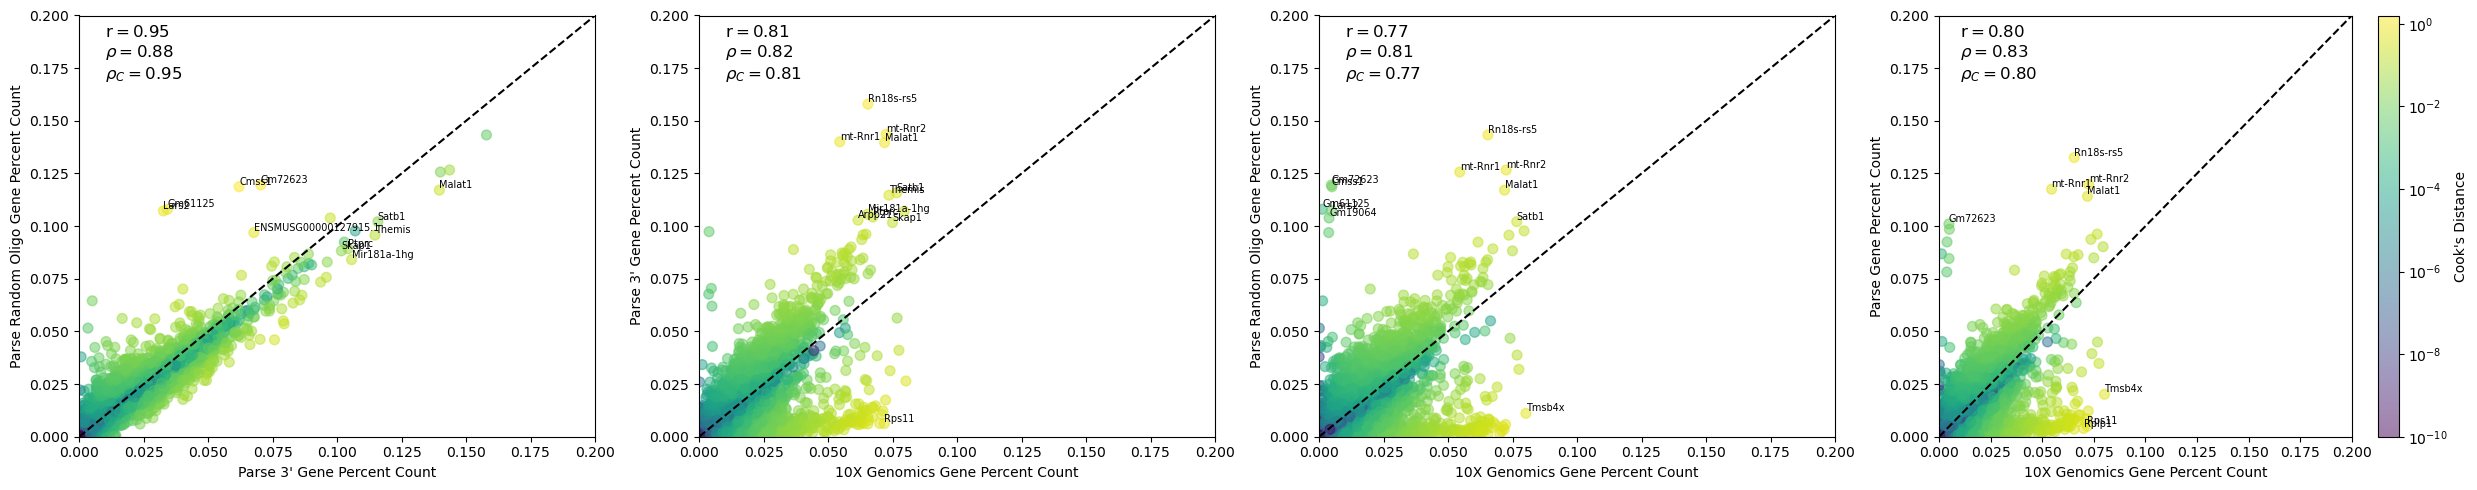

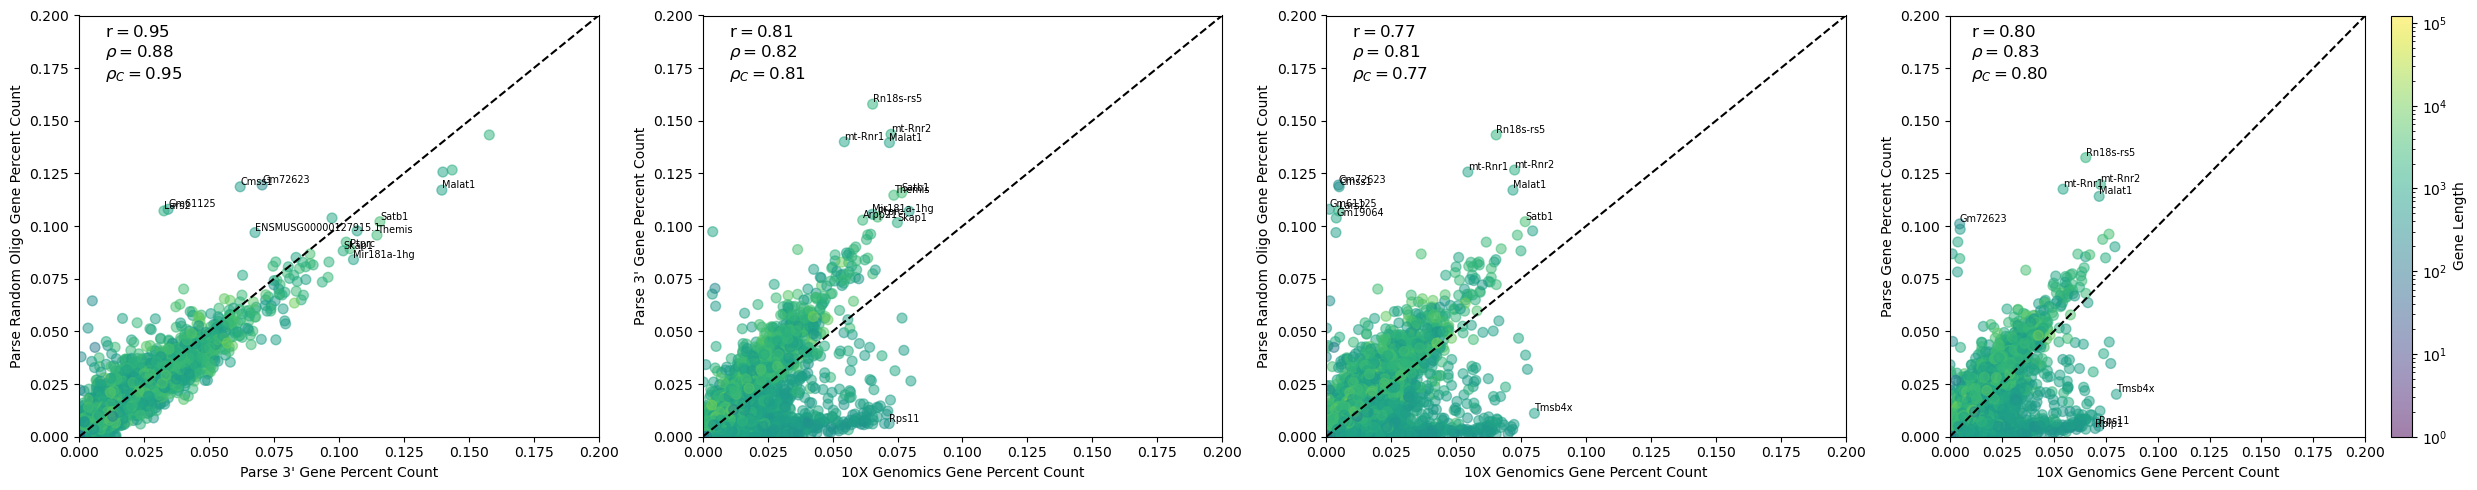

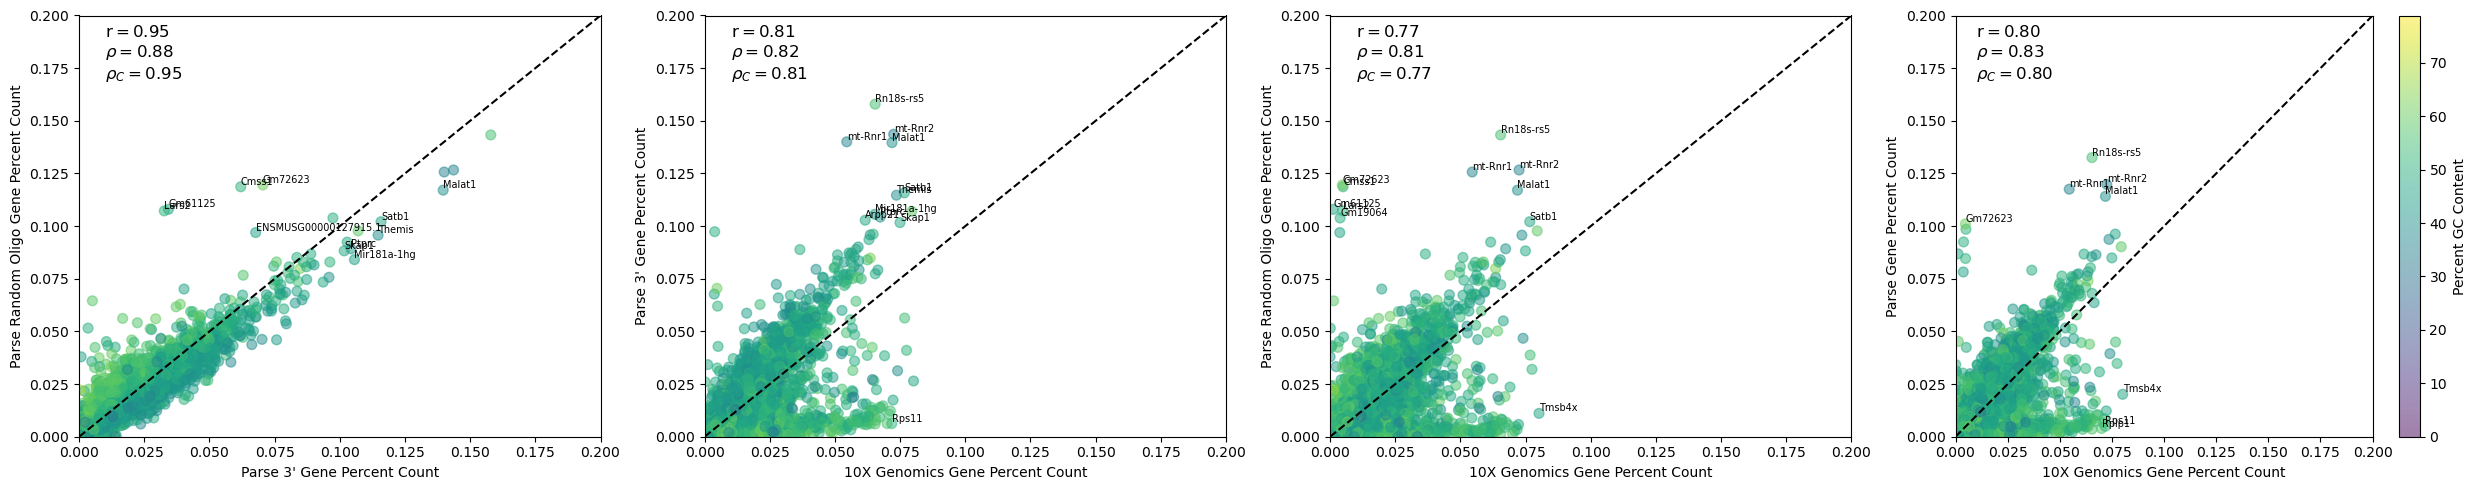

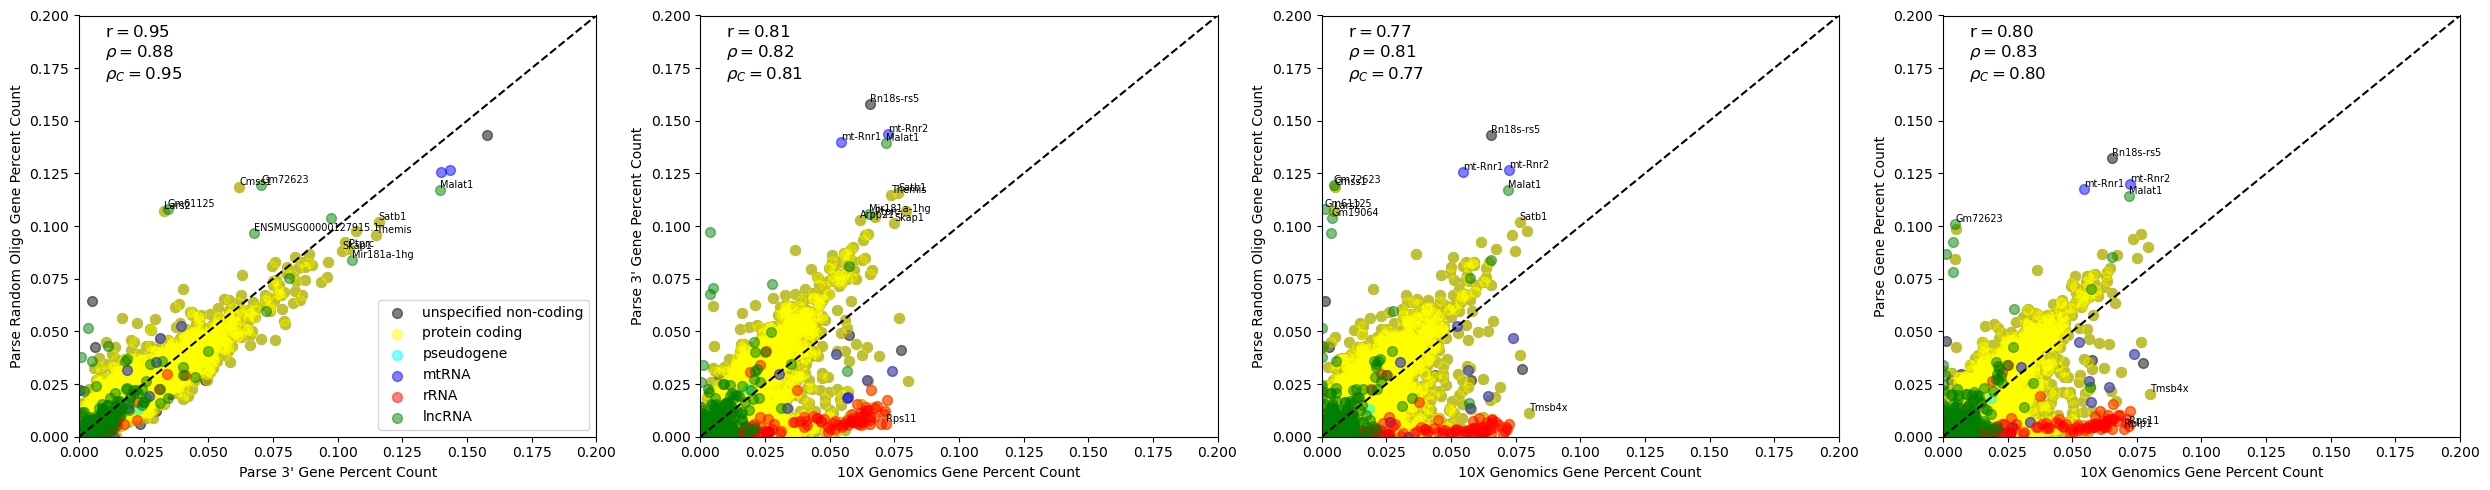

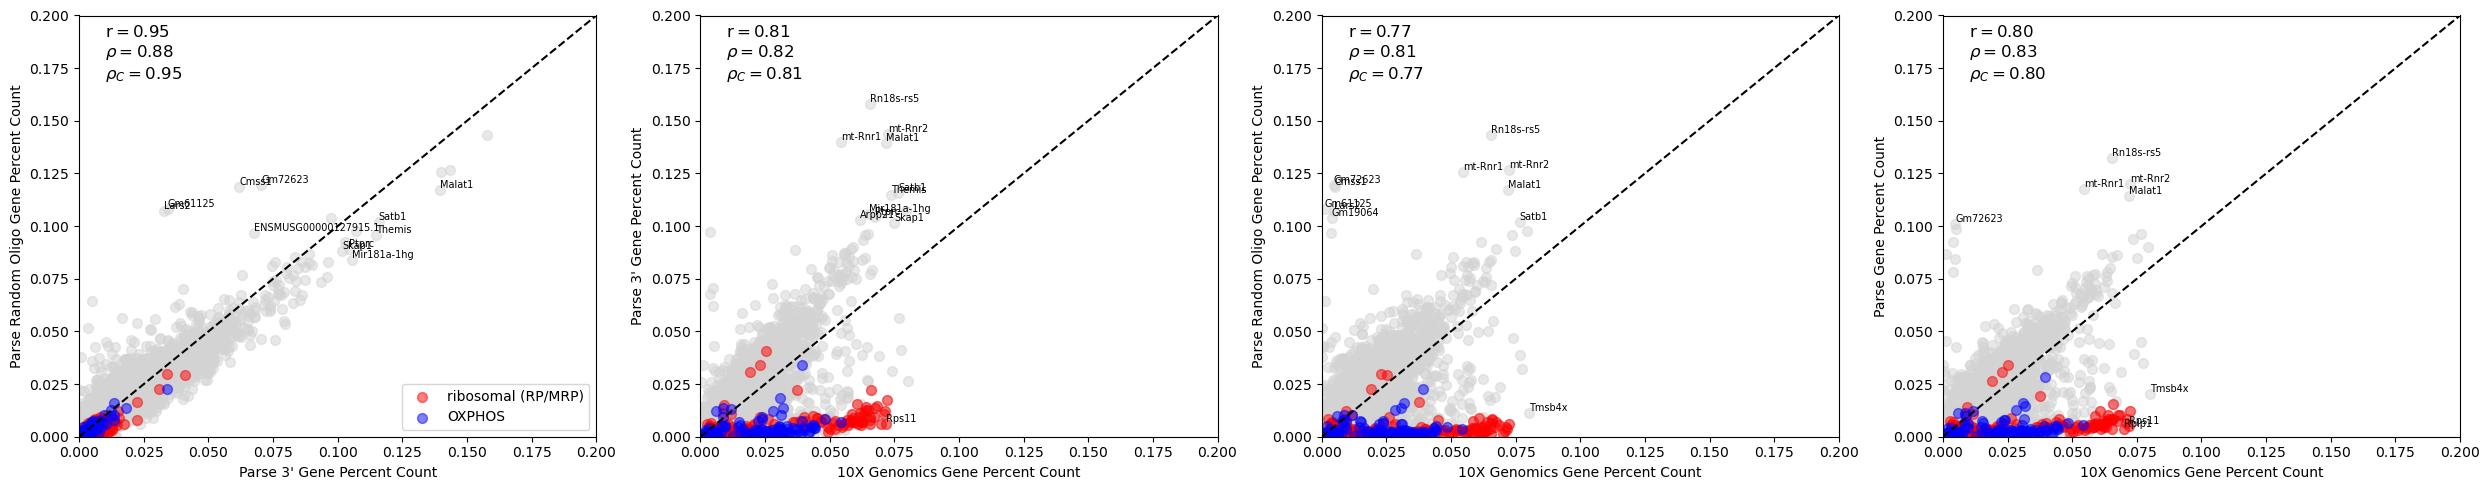

In [23]:
if LOGCPM_TRANSFORM:
    compare_names, compare_dfs = plotting.compare(datasets, 0.2)

In [24]:
if not LOGCPM_TRANSFORM:
    compare_names, compare_dfs = plotting.compare(datasets, 8)

In [25]:
if not LOGCPM_TRANSFORM:
    _, _ = plotting.compare(datasets, 1.5)

In [26]:
if not LOGCPM_TRANSFORM:
    _, _ = plotting.compare(datasets, 0.5)

In [27]:
if LOGCPM_TRANSFORM:
    lim = 0.2
else:
    lim = 1.2

In [28]:
data_10x = datasets[0]
data_polyT = datasets[1]
data_randO = datasets[2]
data_parse = datasets[3]

comparisons = [(data_polyT, data_randO),
                (data_10x, data_polyT),
                (data_10x, data_randO),
                (data_10x, data_parse)]

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 4 genes in "Mitochondrial Inner Membrane (GO:0005743)" but missing from data:
  ['ATP5MG', 'ATP5PO', 'IFI6', 'UQCRH']
  warnings.warn(
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 7 genes in "Mitochondrial Membrane (GO:0031966)" but missing from data:
  ['ATP5MG', 'ATP5PO', 'IFI27L1', 'IFI27L2', 'IFI6', 'TMEM14B', 'UQCRH']
  warnings.warn(
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 20 genes in "Extracellular Exosome (GO:0070062)" but missing from data:
  ['AKR1C3', 'AKR1C4', 'AKR7A2', 'CD248', 'CETP', 'EIF2S3', 'GAL3ST4', 'GLOD4', 'H2AC4', 'H2AC6', 'H2BC9', 'HLA-C', 'HLA-DRB1', 'HLA-E', 'HSPA1B', 'HSPA6', 'LDHAL6A', 'RBP5', 'RPL26L1', 'S100P']
  warnings.warn(
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 20 genes in "Extracellular 

  Parse 3' vs Parse Random Oligo | Mitochondrial Inner Membrane (GO:0005743): 121/213 toward Parse 3', 92/213 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Mitochondrial Membrane (GO:0031966): 143/263 toward Parse 3', 120/263 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Extracellular Exosome (GO:0070062): 226/523 toward Parse 3', 297/523 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Extracellular Vesicle (GO:1903561): 226/526 toward Parse 3', 300/526 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Large Ribosomal Subunit (GO:0015934): 42/52 toward Parse 3', 10/52 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Mitochondrial Inner Membrane (GO:0005743): 209/215 toward 10X Genomics, 6/215 toward Parse 3'
  10X Genomics vs Parse 3' | Mitochondrial Membrane (GO:0031966): 252/265 toward 10X Genomics, 13/265 toward Parse 3'
  10X Genomics vs Parse 3' | Extracellular Exosome (GO:0070062): 465/529 toward 10X Genomics, 64/529 tow

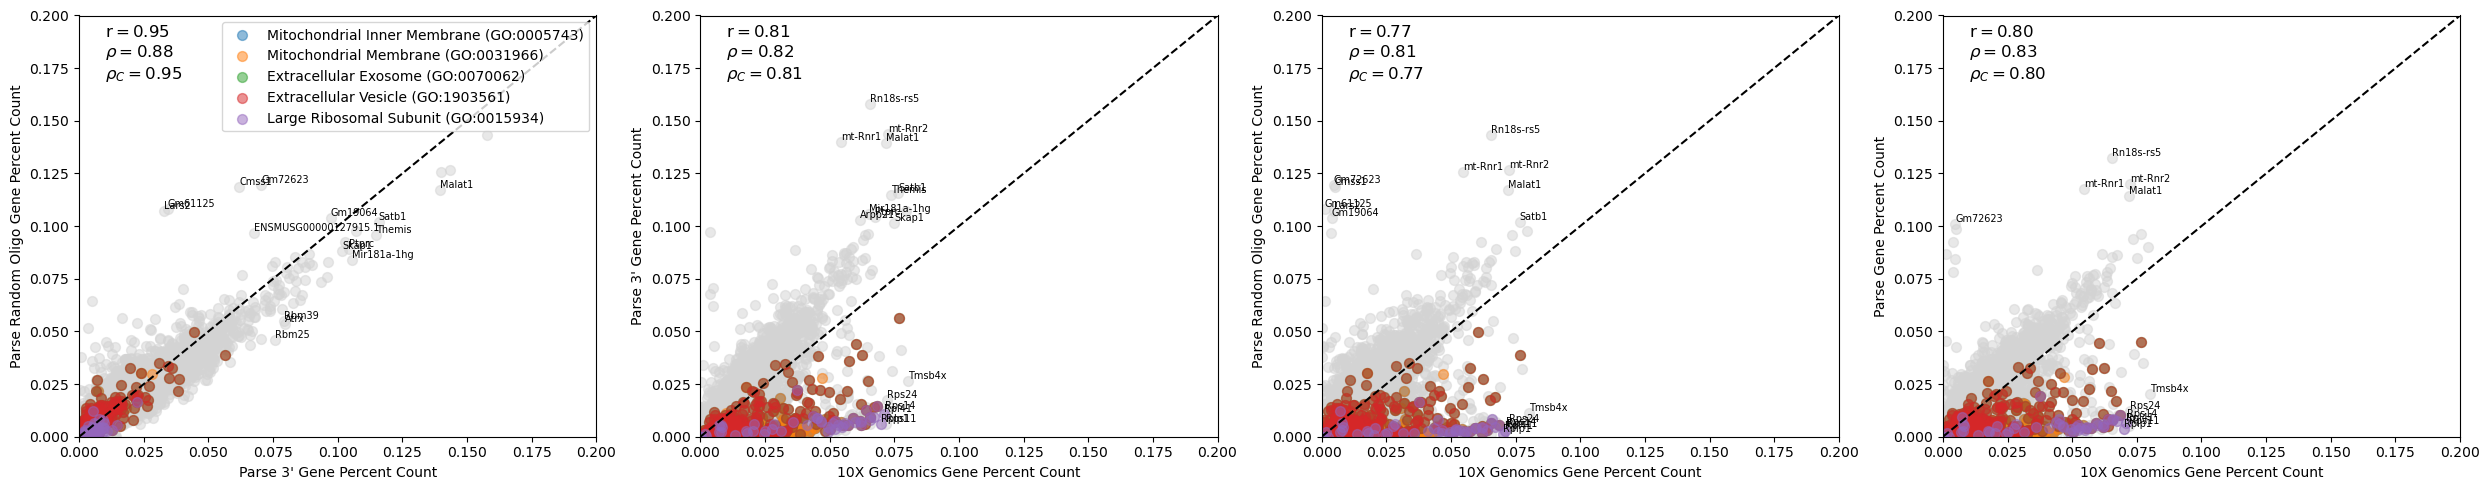

In [29]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Cellular_Component_2026"],
    terms=["Extracellular Exosome (GO:0070062)", "Extracellular Vesicle (GO:1903561)", "Mitochondrial Membrane (GO:0031966)", "Large Ribosomal Subunit (GO:0015934)", "Mitochondrial Inner Membrane (GO:0005743)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 1 genes in "Mouse Housekeeping Genes" but missing from data:
  ['']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | Mouse Housekeeping Genes: 576/1147 toward Parse 3', 571/1147 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Mouse Housekeeping Genes: 699/1150 toward 10X Genomics, 451/1150 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Mouse Housekeeping Genes: 659/1152 toward 10X Genomics, 493/1152 toward Parse Random Oligo
  10X Genomics vs Parse | Mouse Housekeeping Genes: 639/1151 toward 10X Genomics, 512/1151 toward Parse


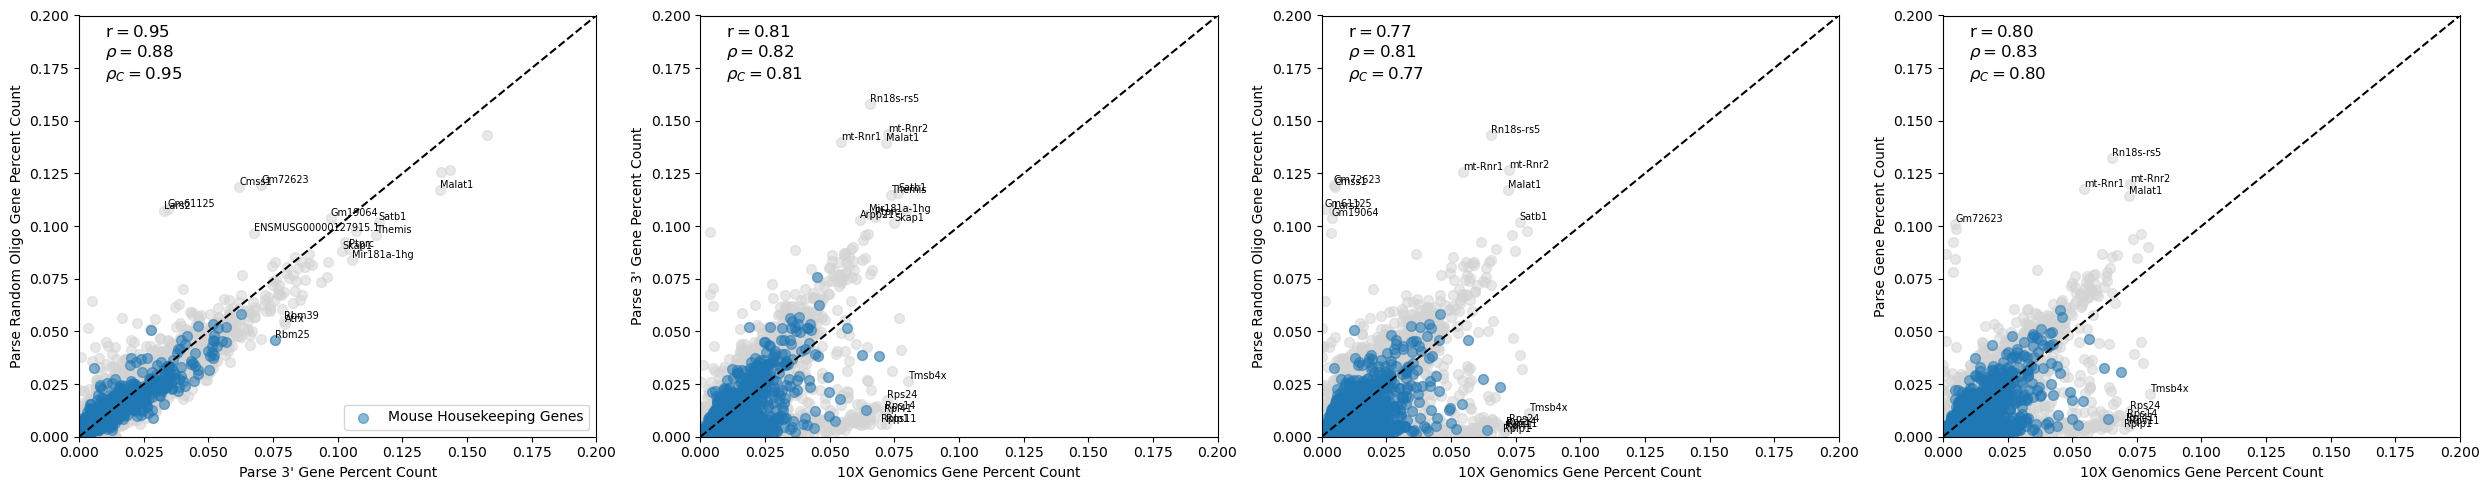

In [30]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/important_gene_sets.csv",
    gene_sets=["Housekeeping"],
    terms=["Mouse Housekeeping Genes"])

  Parse 3' vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=5037): 1307/3183 toward Parse 3', 1876/3183 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Higher in Parse 3' Human PBCMS (n=3364): 757/1476 toward Parse 3', 719/1476 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Higher in 10x Genomics Human PBMCS (n=5037): 2736/3197 toward 10X Genomics, 461/3197 toward Parse 3'
  10X Genomics vs Parse 3' | Higher in Parse 3' Human PBCMS (n=3364): 299/1474 toward 10X Genomics, 1175/1474 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=5037): 2368/3211 toward 10X Genomics, 843/3211 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Higher in Parse 3' Human PBCMS (n=3364): 278/1475 toward 10X Genomics, 1197/1475 toward Parse Random Oligo
  10X Genomics vs Parse | Higher in 10x Genomics Human PBMCS (n=5037): 2481/3207 toward 10X Genomics, 726/3207 toward Parse
  10X Genomics vs Parse | Higher in Parse 3'

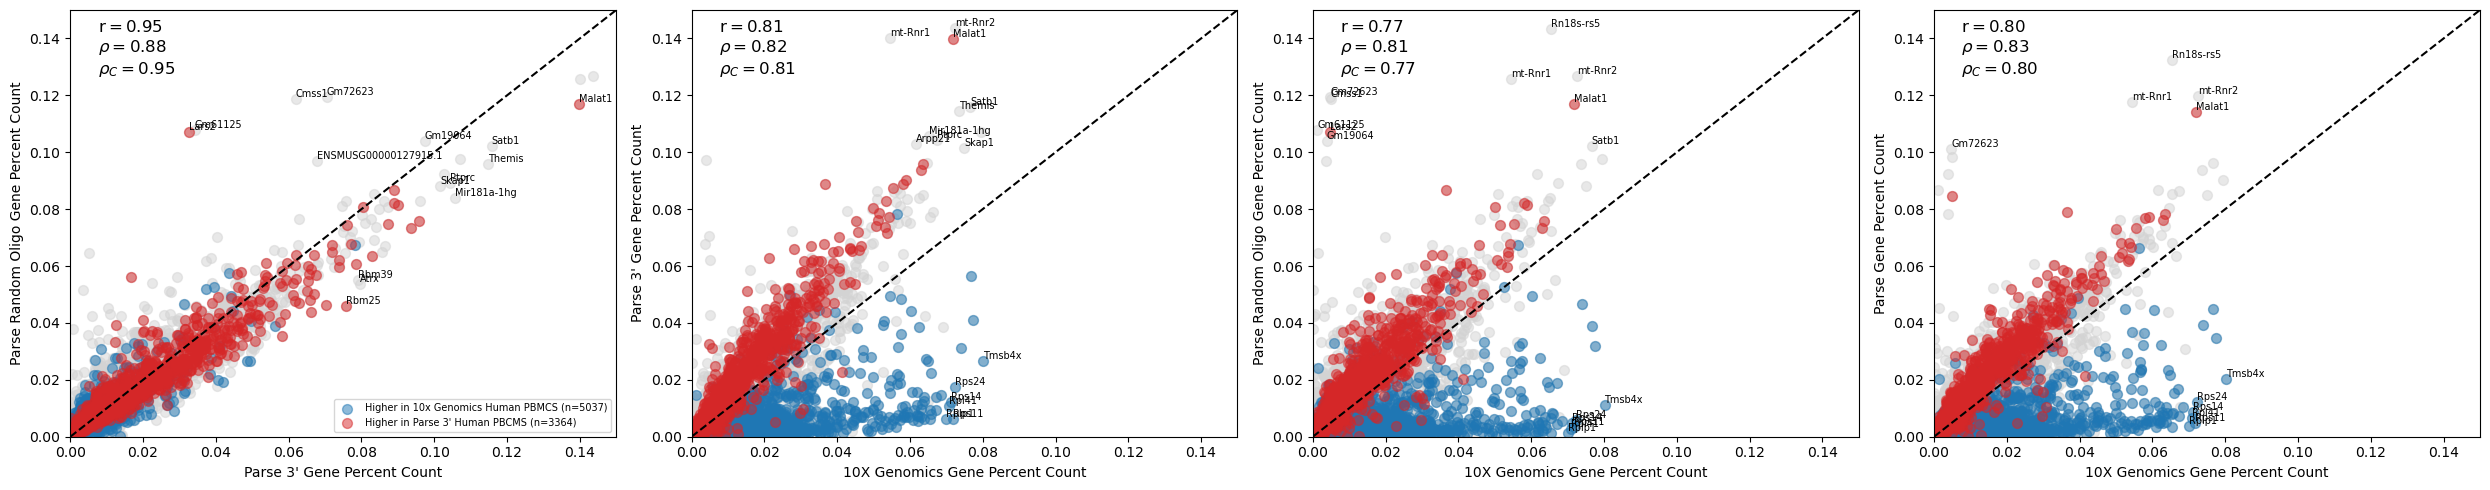

In [31]:
results= pd.read_csv("/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/results.csv")

plotting.compare_by_de(
    compare_dfs, comparisons, lim=0.15,
    de_results=results,              # DataFrame from perform_edgepy
    de_comparing=("10x Genomics Human PBMCS", "Parse 3' Human PBCMS"),   # the two sides
    fdr_thresh=0.01,
)

  Parse 3' vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=4953): 1409/2950 toward Parse 3', 1541/2950 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Higher in Parse Human PBCMS (n=3590): 584/1627 toward Parse 3', 1043/1627 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Higher in 10x Genomics Human PBMCS (n=4953): 2544/2970 toward 10X Genomics, 426/2970 toward Parse 3'
  10X Genomics vs Parse 3' | Higher in Parse Human PBCMS (n=3590): 419/1623 toward 10X Genomics, 1204/1623 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=4953): 2373/2985 toward 10X Genomics, 612/2985 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Higher in Parse Human PBCMS (n=3590): 278/1627 toward 10X Genomics, 1349/1627 toward Parse Random Oligo
  10X Genomics vs Parse | Higher in 10x Genomics Human PBMCS (n=4953): 2435/2982 toward 10X Genomics, 547/2982 toward Parse
  10X Genomics vs Parse | Higher in Parse Human PBCM

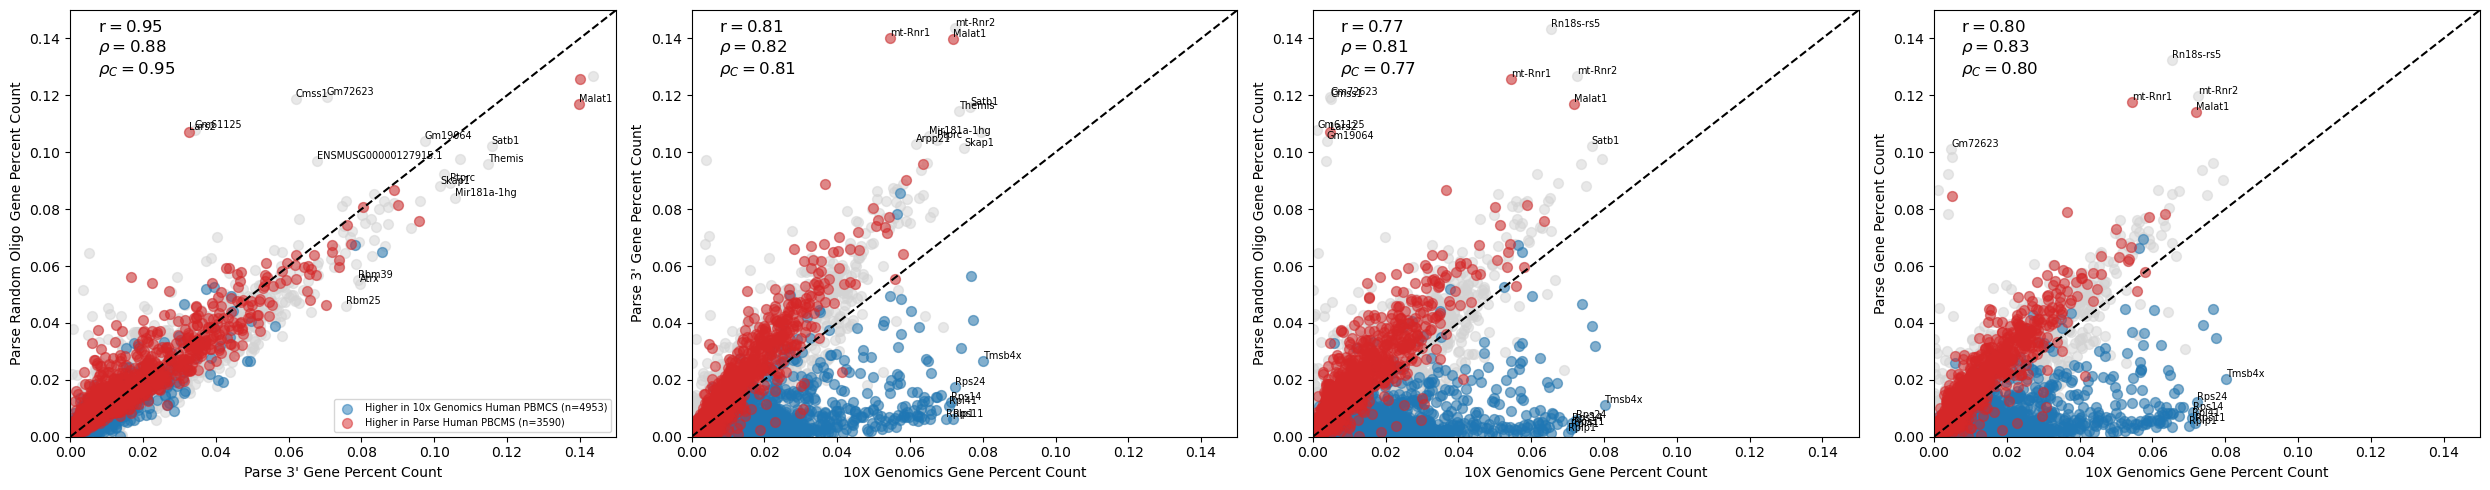

In [32]:
results= pd.read_csv("/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/results.csv")

plotting.compare_by_de(
    compare_dfs, comparisons, lim=0.15,
    de_results=results,              # DataFrame from perform_edgepy
    de_comparing=("10x Genomics Human PBMCS", "Parse Human PBCMS"),   # the two sides
    fdr_thresh=0.01,
)

  Parse 3' vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=5177): 2418/3029 toward Parse 3', 611/3029 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Higher in Parse Human PBCMS (n=5679): 486/3900 toward Parse 3', 3414/3900 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Higher in 10x Genomics Human PBMCS (n=5177): 1228/3054 toward 10X Genomics, 1826/3054 toward Parse 3'
  10X Genomics vs Parse 3' | Higher in Parse Human PBCMS (n=5679): 2325/3890 toward 10X Genomics, 1565/3890 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=5177): 1607/3053 toward 10X Genomics, 1446/3053 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Higher in Parse Human PBCMS (n=5679): 1263/3907 toward 10X Genomics, 2644/3907 toward Parse Random Oligo
  10X Genomics vs Parse | Higher in 10x Genomics Human PBMCS (n=5177): 1369/3061 toward 10X Genomics, 1692/3061 toward Parse
  10X Genomics vs Parse | Higher in Parse Human 

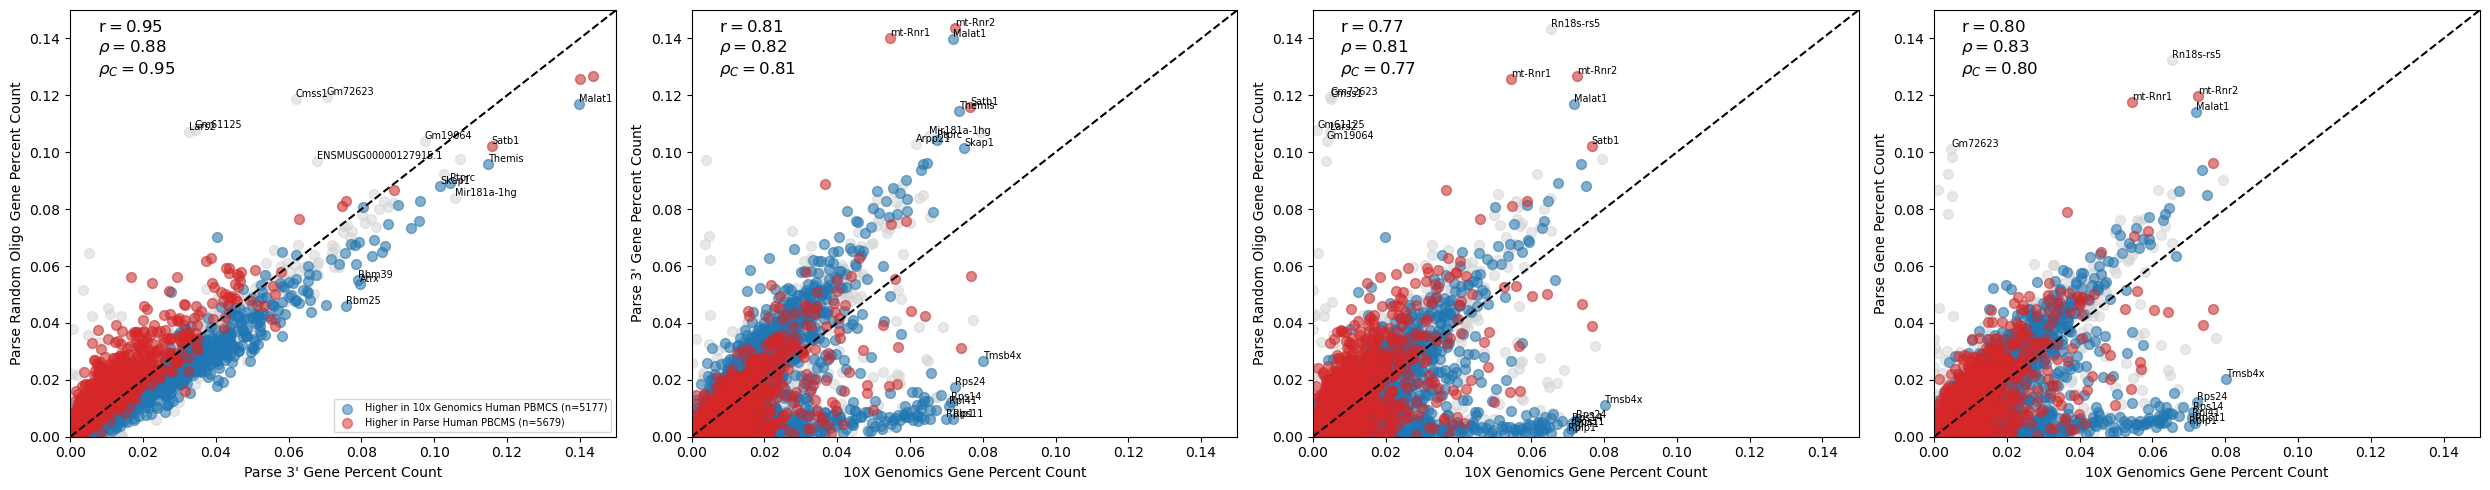

In [33]:
results= pd.read_csv("/home/mcaskey/10XvParse/Notebooks/Comparisons/PolyTvRandO/results.csv")

plotting.compare_by_de(
    compare_dfs, comparisons, lim=0.15,
    de_results=results,              # DataFrame from perform_edgepy
    de_comparing=("10x Genomics Human PBMCS", "Parse Human PBCMS"),   # the two sides
    fdr_thresh=0.01,
)

In [34]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)
gene_info.to_csv(FULL_GENE_INFO_PATH)